<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.
___

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.
___

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

___
# **Importing necessary libraries**

In [64]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

# Core libraries
import math
import joblib
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data splitting and tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

#  EDA
import sweetviz as sv

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

# Metrics
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Display
from IPython.display import display, Markdown

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

# To set the target column name
TARGET_COL = "case_status"
id_cols = "case_id"

%matplotlib inline

# Label encoder
le = LabelEncoder()

___
# **Loading the dataset**

In [6]:
visa = pd.read_csv("EasyVisa.csv") 
sensor = pd.read_csv("Train.csv") 


In [7]:
df = visa.copy() # copying data to another variable to avoid any changes to original data
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


___
# **Overview of the Dataset**

In [8]:
print(f" Number of rows and columns in the dataset: {df.shape}")

print("==========================================================")
df.info()

 Number of rows and columns in the dataset: (25480, 12)
<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


* Observations

      The dataset contains 25,480 records with 12 columns, all of which are fully populated with no missing values. Most fields are categorical (9 object‑type columns), while only three are numeric. Memory usage is modest at around 2.3 MB, and the structure suggests a clean, well‑formed dataset suitable for modeling or exploratory analysis.

___
# **Basic Data Quality Checks**

In [9]:
# Check for missing values

report = sv.analyze(visa)
report.show_html("Visa_Report.html")

# Inline (in notebook)
report

                                             |          | [  0%]   00:00 -> (? left)

Report Visa_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## **Data Sanity Checks Summary table**

In [14]:
# Base summary 
dq = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nunique": df.nunique(dropna=False),
    "missing": 0,
    "missing_%": 0
})

# Duplicate summary
dup = pd.DataFrame({
    "duplicate_rows": [df.duplicated().sum()],
    "duplicate_case_id": [df["case_id"].duplicated().sum()] if "case_id" in df.columns else [0]
}, index=["duplicate_summary"])


# Numeric sanity checks
numeric_var= df.select_dtypes(include=[np.number]).columns

if len(numeric_var):
    numeric = pd.DataFrame({
        "negatives": (df[numeric_var] < 0).sum(),
        "zeros": (df[numeric_var] == 0).sum(),
        "infinite": np.isinf(df[numeric_var]).sum()
    })
else:
    numeric = pd.DataFrame(index=df.columns, columns=["negatives","zeros","infinite"]).fillna(0)

# Combine all summaries
final_df = dq.join(numeric.reindex(dq.index))
final_df = pd.concat([final_df, dup], axis=0)

# Force all numeric columns to integer
int_cols = ["non_null","nunique","missing","missing_%","negatives","zeros","infinite",
            "duplicate_rows","duplicate_case_id"]

for col in int_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(0).astype(int)

final_df


,dtype,non_null,nunique,missing,missing_%,negatives,zeros,infinite,duplicate_rows,duplicate_case_id
case_id,str,25480,25480,0,0,0,0,0,0,0
continent,str,25480,6,0,0,0,0,0,0,0
education_of_employee,str,25480,4,0,0,0,0,0,0,0
has_job_experience,str,25480,2,0,0,0,0,0,0,0
requires_job_training,str,25480,2,0,0,0,0,0,0,0
no_of_employees,int64,25480,7105,0,0,33,0,0,0,0
yr_of_estab,int64,25480,199,0,0,0,0,0,0,0
region_of_employment,str,25480,5,0,0,0,0,0,0,0
prevailing_wage,float64,25480,25454,0,0,0,0,0,0,0
unit_of_wage,str,25480,4,0,0,0,0,0,0,0


#### Summary of quality data checks from Profiling Report ([Appendix A](Automated_Data_Profiling_Report.html))

| Category                               | Finding                                                  | Evidence from Report                                         | Risk Level           | Suggested Fix                                                                                             |
| -------------------------------------- | -------------------------------------------------------- | ------------------------------------------------------------ | -------------------- | --------------------------------------------------------------------------------------------------------- |
| **Dataset Overview**                   | 25,480 observations, 12 variables                        | Dataset statistics show 12 variables and 25,480 records      | Low                  | No action required                                                                                        |
| **Missing Values**                     | 0 missing values                                         | Missing cells: 0 (0.0%)                                      | Low                  | No imputation required                                                                                    |
| **Duplicate Rows**                     | No duplicate rows                                        | Duplicate rows: 0                                            | Low                  | No action required                                                                                        |
| **Negative Values (Numeric)**          | Negative values present (e.g., -26, -25, -17 etc.)       | Extreme minimum values shown for numeric variable            | **High**             | Replace invalid negatives with absolute values OR investigate source system for data entry errors |
| **Extreme Outliers (Numeric)**         | Very high maximum values (e.g., 602,069)                 | Max value = 602,069                                          | High                 | Apply log transformation, winsorization, or cap at 99th percentile                                        |
| **Skewness (Wage-like Variable)**      | Positively skewed distribution (Skewness ≈ 0.76)         | Skewness = 0.755                                             | Medium               | Apply log transformation before modeling                                                                  |
| **Kurtosis (Heavy Tails)**             | Extremely high kurtosis (~206) in one numeric variable   | Kurtosis = 206.33                                            | High                 | Investigate outliers/ cap extreme values                                                                  |
| **Year Variable (yr_of_estab)**        | Wide range: 1800–2016                                    | Min = 1800, Max = 2016                                       | Medium               | Validate whether pre-1900 values are realistic; optionally cap at reasonable business threshold           |
| **Class Imbalance (Boolean Variable)** | Strong imbalance: 88% False vs 13% True                  | Distribution shown: 22,525 vs 2,955                          | High (Modeling Risk) | Use class_weight='balanced', SMOTE, or undersampling                                                      |
| **Categorical Cardinality**            | Some categorical variables have moderate distinct levels | Distinct values (e.g., yr_of_estab has 199 distinct values)  | Low–Medium           | Use OneHotEncoder with handle_unknown='ignore'                                                            |
| **Memory Usage**                       | Small dataset (2.3 MiB total)                            | Total size = 2.3 MiB                                         | Low                  | No optimization required                                                                                  |
| **Data Distribution Spread**           | Large IQR and wide range (e.g., Range ≈ 319,208)         | Range and IQR stats                                          | Medium               | Consider scaling (RobustScaler)                                                                           |


**Overall Assessment**
- The dataset is broadly usable but requires targeted cleaning—particularly around numeric validity, outlier control, and distributional adjustments—to ensure stable, unbiased model performance.

___
# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- Binary classification task predicting **visa certification outcomes** using mixed numeric and categorical features.  
- Analysis highlights **moderate class imbalance** and distribution issues such as skew and outliers [(See Appendix A)](Automated_Data_Profiling_Report.html).  
- Focus is on understanding **key applicant and employer attributes** that influence certification decisions.

In [15]:
# EDA: Identify numeric and categorical columns

df_eda = df.copy()

features = [c for c in df_eda.columns if c not in [id_cols, TARGET_COL]]

X_eda = df_eda[features].copy()
num_var = X_eda.select_dtypes(include=[np.number]).columns.tolist()
cat_var = [c for c in X_eda.columns if c not in num_var]

print("ID cols:", id_cols)
print("Numeric cols:", num_var)
print("Categorical cols:", cat_var)

ID cols: case_id
Numeric cols: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical cols: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position']


___

## <a>**Univariate Analysis — Distribution and Outlier Assessment**</a>

- Examines variable distributions and outlier patterns using insights from the profiling report [(See Appendix A)](Automated_Data_Profiling_Report.html).
- Boxplots and IQR‑based summaries reveal skewness and extreme values, particularly within numerical features.

### **Target Distribution (Univariate)**

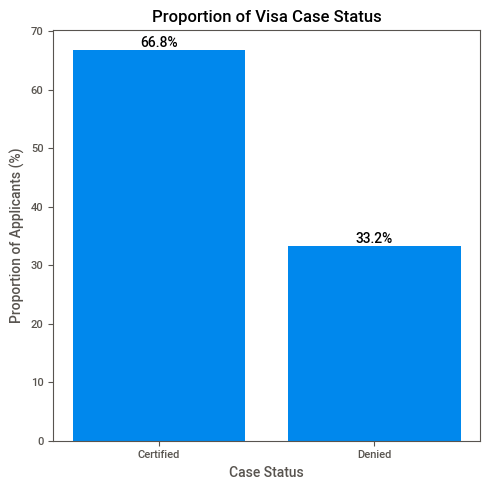

In [16]:
# EDA:Target Distribution (Univariate)

cs_pct = (df_eda[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2)

plt.figure(figsize=(5,5))
plt.bar(cs_pct.index.astype(str), cs_pct.values)

for i, v in enumerate(cs_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.title("Proportion of Visa Case Status")
plt.ylabel("Proportion of Applicants (%)")
plt.xlabel("Case Status")
plt.tight_layout()
plt.show()



**Visa certifications make up roughly two‑thirds of all cases, indicating a moderate class imbalance but no severe skew in the target distribution.**

### **Numeric (Univariate)**

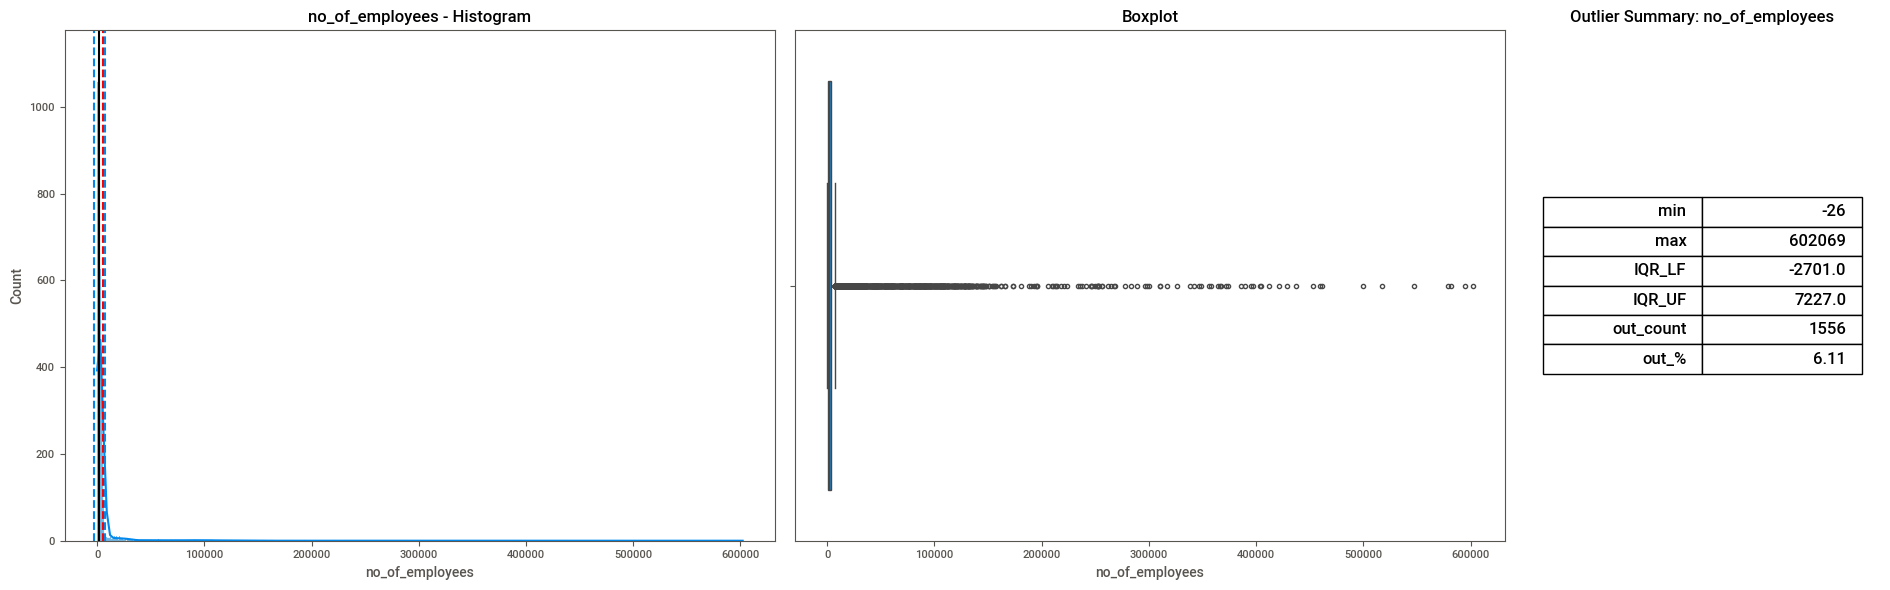

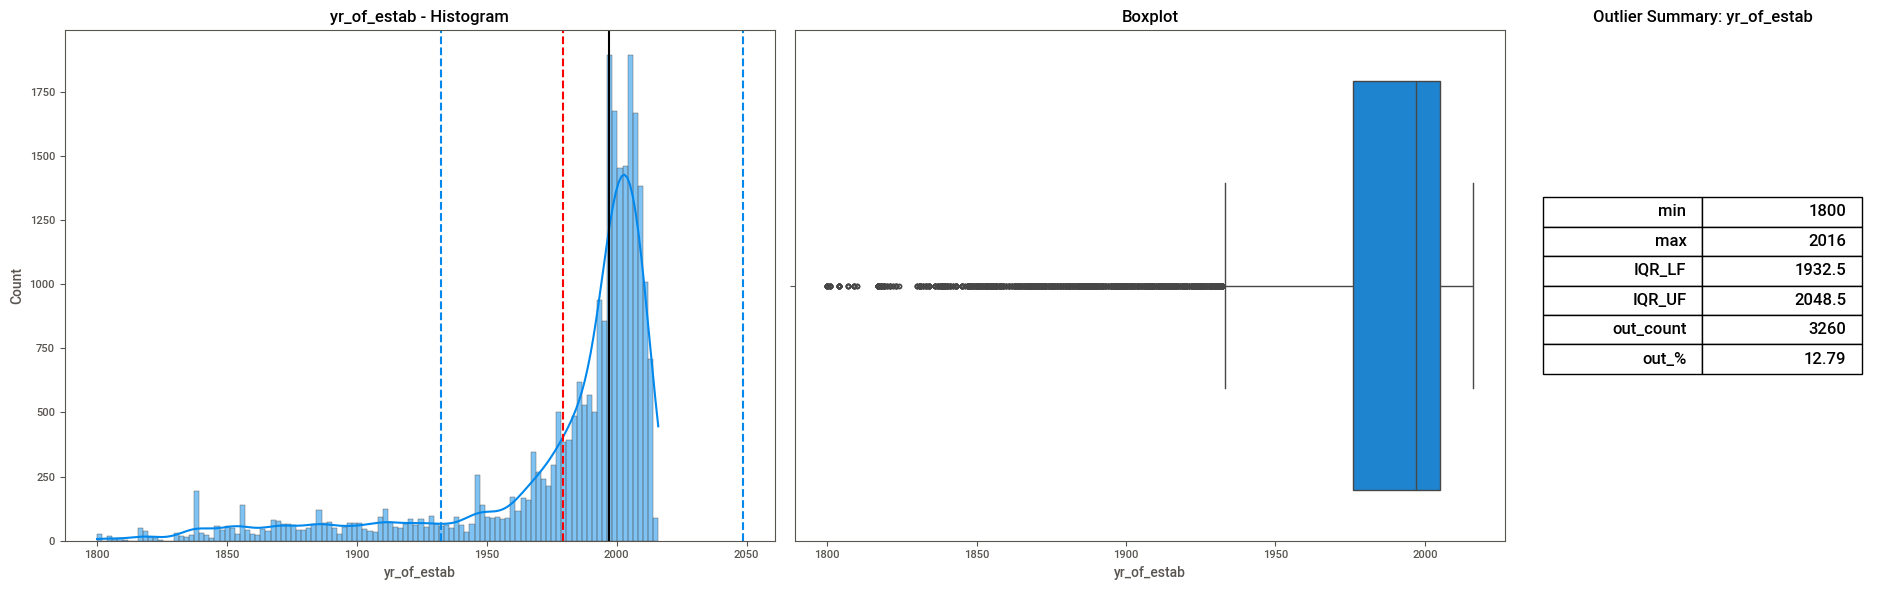

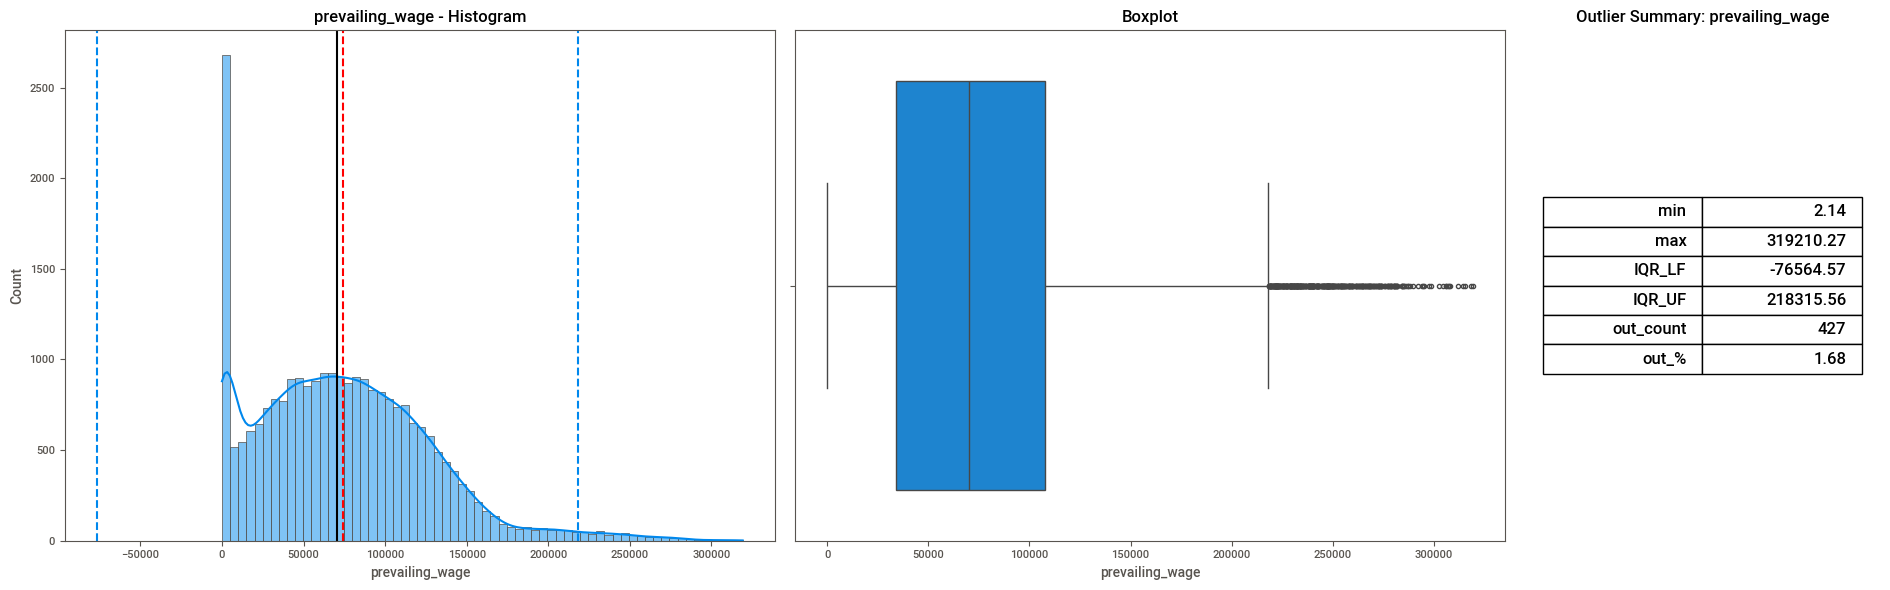

In [17]:
# Numeric Distribution (Univariate)

for c in num_var:
    s = df_eda[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lf, uf = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_count = ((s < lf) | (s > uf)).sum()
    out_pct = round(out_count / len(s) * 100, 2)

    fig, ax = plt.subplots(1, 3, figsize=(19, 6),
                           gridspec_kw={'width_ratios':[2,2,1]})

    # Histogram
    sns.histplot(s, kde=True, ax=ax[0])
    ax[0].set_title(f"{c} - Histogram")
        # Add vertical lines for IQR bounds
    ax[0].axvline(lf, ls="--"); ax[0].axvline(uf, ls="--")
        # Add mean and median
    ax[0].axvline(s.mean(), color="red", linestyle="--")   # mean
    ax[0].axvline(s.median(), color="black", linestyle="-")  # median

    # Standard Boxplot for outlier visualization
    sns.boxplot(x=s, ax=ax[1])
    ax[1].set_title("Boxplot")

    # Outlier summary table
    ax[2].axis("off")
    tbl = ax[2].table(
        cellText=[
            ["min", round(s.min(),2)],
            ["max", round(s.max(),2)],
            ["IQR_LF", round(lf,2)],
            ["IQR_UF", round(uf,2)],
            ["out_count", int(out_count)],
            ["out_%", out_pct]
        ],
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(0.9, 1.6)
    ax[2].set_title(f"Outlier Summary: {c}")

    plt.tight_layout()
    plt.show()

**Summary of Numerical Variables — Univariate Analysis (Aligned with Profiling Report)**

| Variable        | Issue Type                              | Severity | Action Taken                        |
| --------------- | --------------------------------------- | -------- | ----------------------------------- |
| no_of_employees | Extreme skew + impossible negatives     | Medium   | Absolute correction + log transform |
| yr_of_estab     | Historical skew + potential placeholder | Low      | Feature engineered to age           |
| prevailing_wage | Scale inconsistency + skew              | High     | Annualize + log transform          |

**Outliers will be retained because they reflect real variation in the data, are well‑handled by tree‑based models, and can be managed through transformation rather than removal**

### **Categorical (Univariate)**

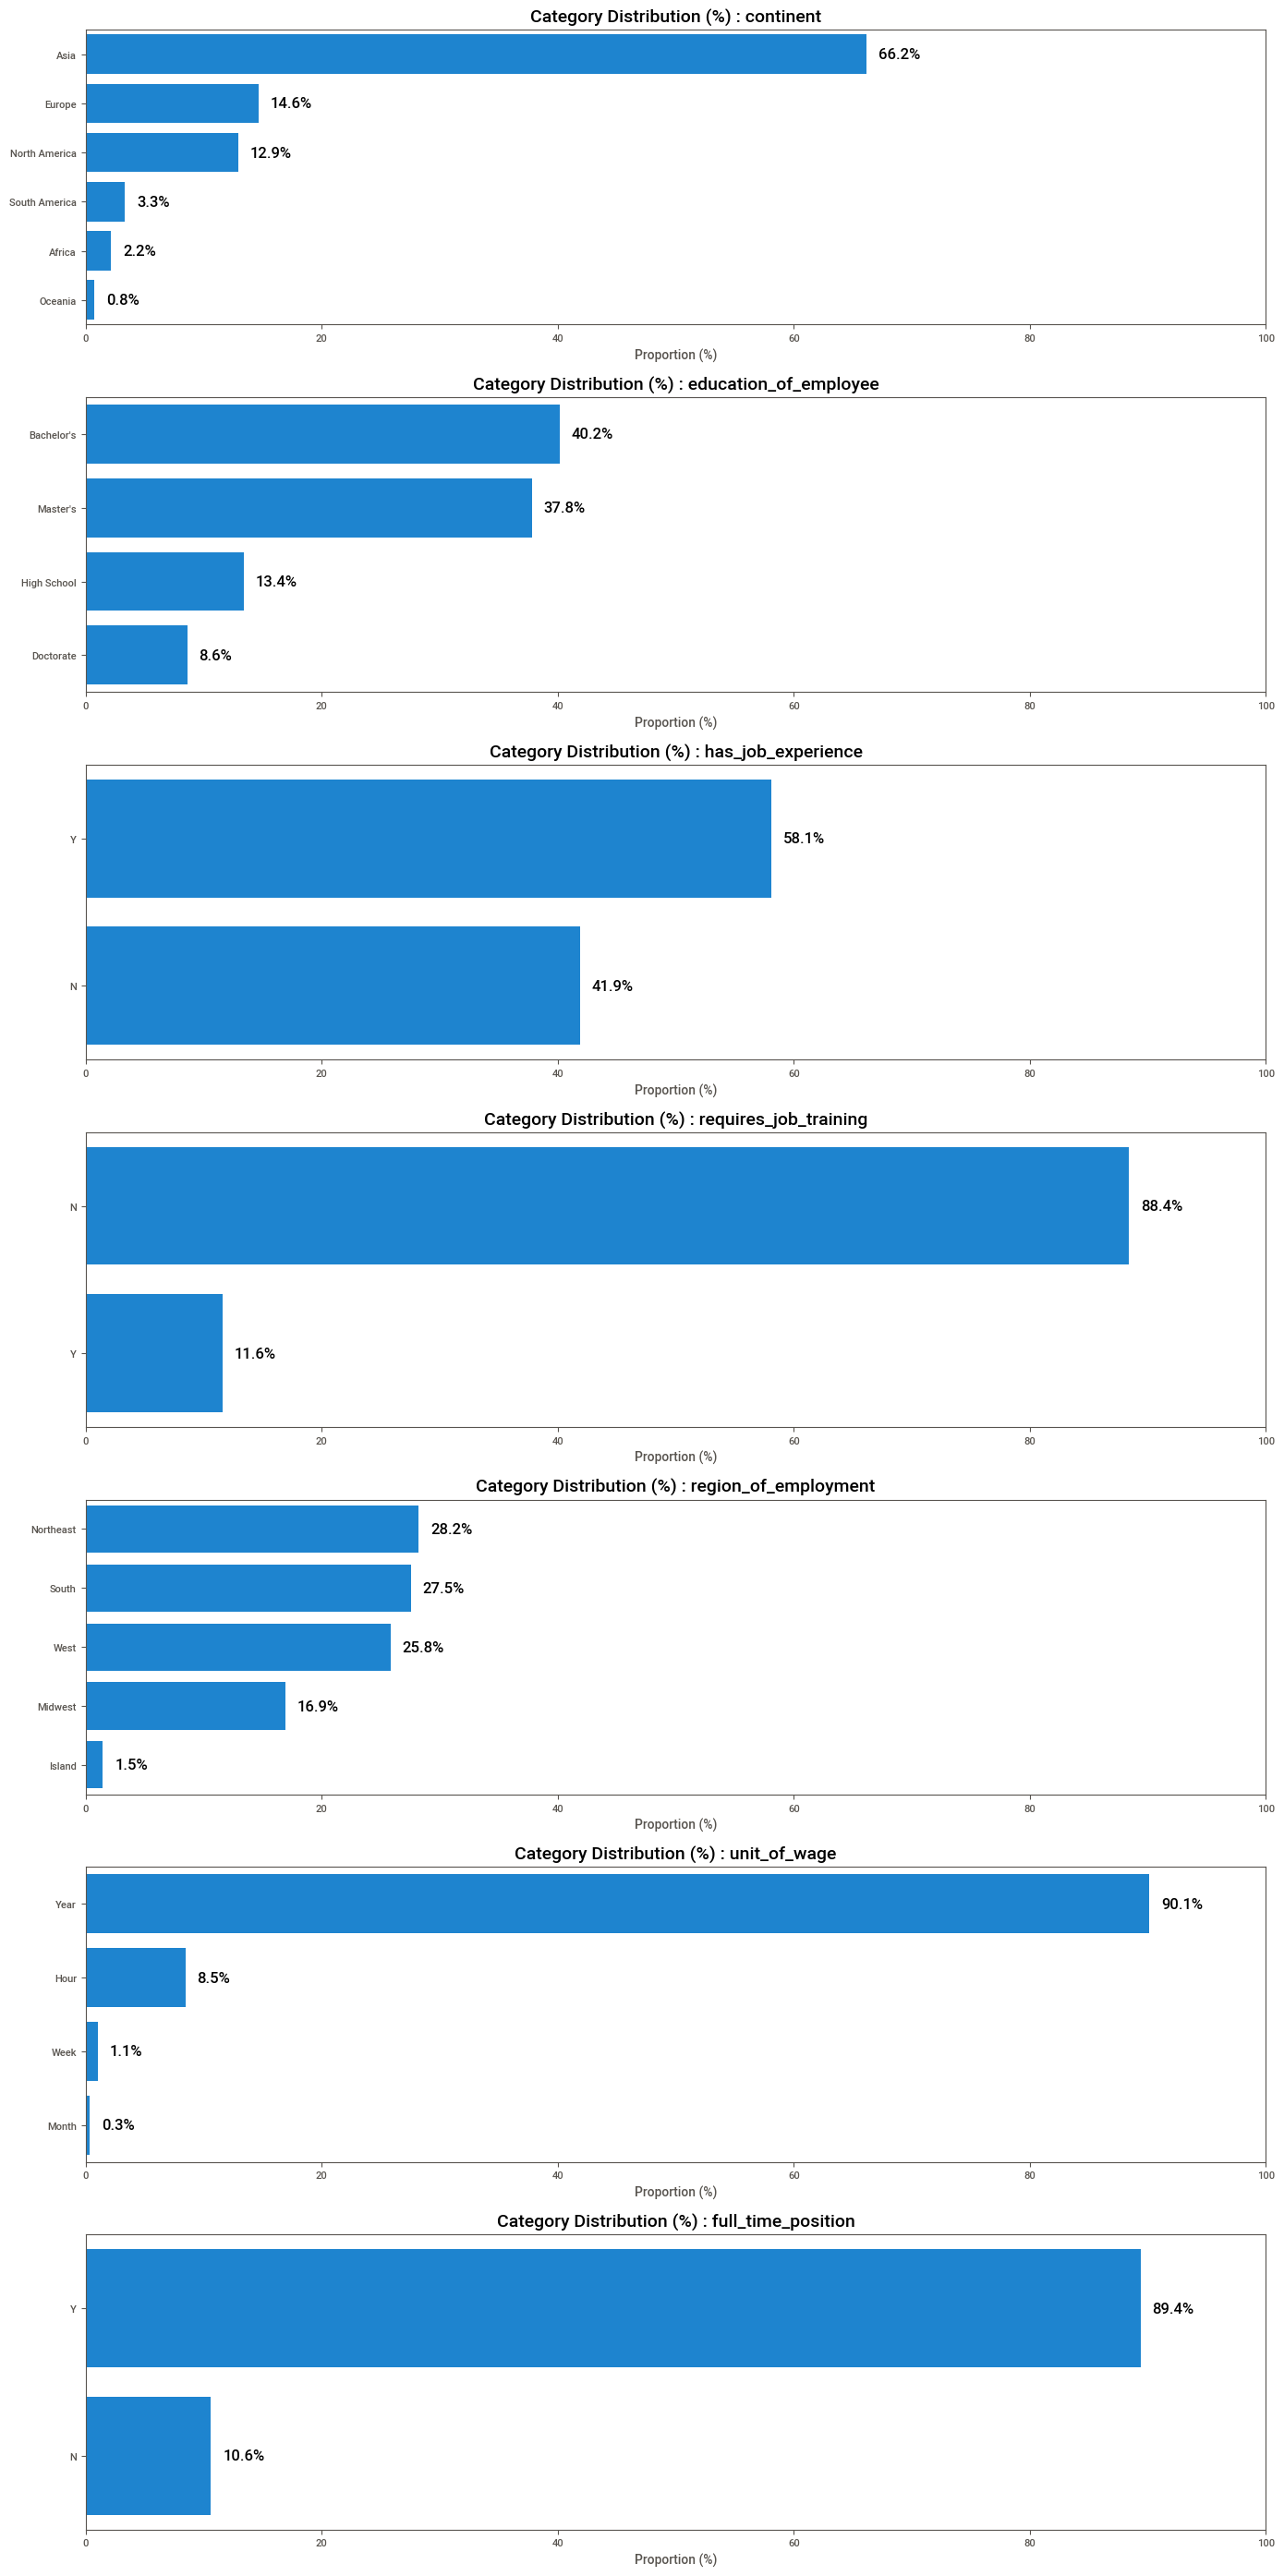

In [18]:
# Categorical (Univariate)

# categorical distribution for each categorical variable    
props = {
    c: df_eda[c].value_counts(dropna=False, normalize=True).sort_values(ascending=False)
    for c in cat_var
}

# Auto height: base + small increment per extra category
total_height = sum(4 + max(0, len(p) - 10) * 0.18 for p in props.values())

fig, axes = plt.subplots(len(cat_var), 1, figsize=(14, total_height))
axes = [axes] if len(cat_var) == 1 else axes

for ax, c in zip(axes, cat_var):
    prop = props[c]
    sns.barplot(x=prop.values * 100, y=prop.index.astype(str), ax=ax)

    ax.set_title(f"Category Distribution (%) : {c}", fontsize=14)
    ax.set_xlabel("Proportion (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

    # Annotate percentages
    for j, v in enumerate(prop.values * 100):
        ax.text(v + 1, j, f"{v:.1f}%", va="center", fontsize=12)

plt.tight_layout()
plt.show()

**Summary of Categorical Variables — Univariate Analysis**

| Variable                  | Key Observation                                                       | Business Insight                                                             |
|---------------------------|-----------------------------------------------------------------------|------------------------------------------------------------------------------|
| **case_status**           | Certifications account for roughly two‑thirds of cases.               | Indicates a moderately imbalanced target with most applications approved.    |
| **continent**             | Majority of applicants originate from Asia.                           | Asia remains the primary source of foreign labor demand.                     |
| **education_of_employee** | Most applicants hold at least a Bachelor’s degree.                    | Sponsorship is concentrated among highly educated workers.                   |
| **has_job_experience**    | Prior job experience is common.                                       | Experience may play a role in certification outcomes.                        |
| **requires_job_training** | Very few roles require additional training.                           | Employers tend to sponsor candidates who are already job‑ready.              |
| **region_of_employment**  | Applications are spread across major U.S. regions.                    | Employment demand is geographically diverse.                                 |
| **unit_of_wage**          | Wages are predominantly reported annually.                            | Annual wage normalization is appropriate for modeling.                       |
| **full_time_position**    | Most positions are full‑time.                                         | Sponsorship is strongly associated with full‑time employment.                |

**Overall, the dataset reflects a skilled, full‑time applicant pool with annual wage reporting, strong representation from Asia, and broad geographic distribution across U.S. regions. These patterns provide a solid foundation for deeper bivariate and multivariate analysis to understand which characteristics most influence visa certification outcomes.**


___

## <a>**Bivariate Analysis — Impact on Visa Approval**</a>

### **Categorical (Bivariate)**

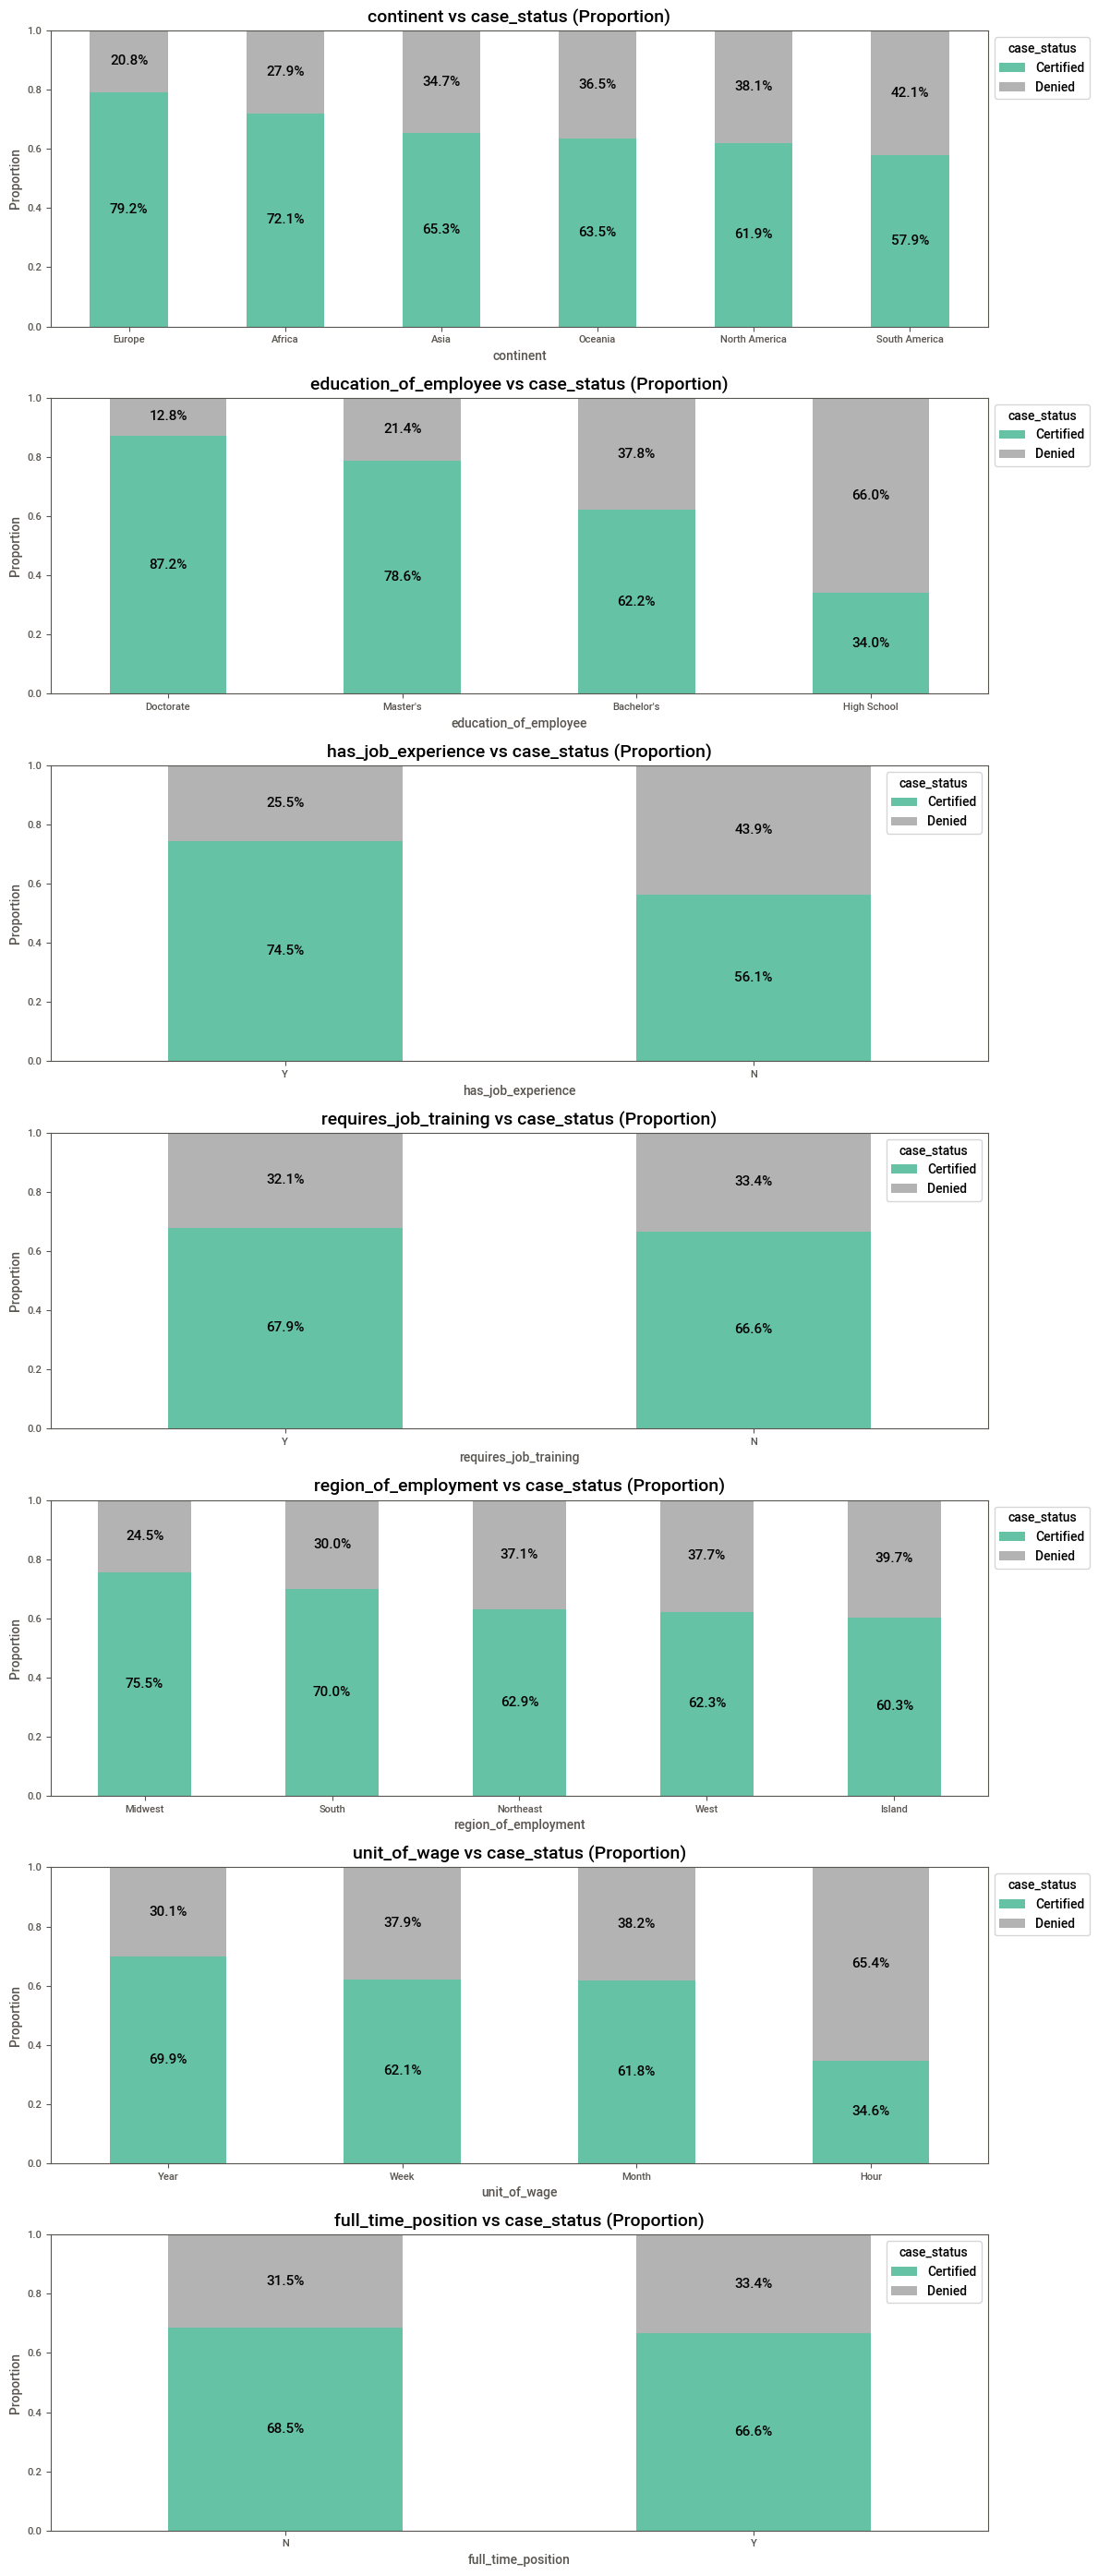

In [19]:
# Bivariate: Categorical predictors vs Target (stacked proportions + % annotations)

fig, axes = plt.subplots(len(cat_var), 1, figsize=(12, 4 * len(cat_var)))
axes = [axes] if len(cat_var) == 1 else axes

# Loop through each categorical variable and plot stacked bar chart of proportions
for ax, c in zip(axes, cat_var):
    prop = pd.crosstab(df_eda[c], df_eda[TARGET_COL], normalize="index")
    if "Certified" in prop.columns:
        prop = prop.sort_values("Certified", ascending=False)

    prop.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
    ax.set_title(f"{c} vs {TARGET_COL} (Proportion)", fontsize=14)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)
    ax.legend(title=TARGET_COL, bbox_to_anchor=(1, 1))
    ax.tick_params(axis="x", rotation=0)

    # Annotate %
    for j, idx in enumerate(prop.index):
        cum = 0
        for cls, v in prop.loc[idx].items():
            if v > 0:
                ax.text(j, cum + v/2, f"{v*100:.1f}%", ha="center", va="center", fontsize=11)
            cum += v

plt.tight_layout()
plt.show()

 **Categorical Variables vs. Visa Certification**

| Variable                  | Key Observation                                                             | Impact | Interpretation                                           |
|---------------------------|-----------------------------------------------------------------------------|--------|----------------------------------------------------------|
| **Continent**             | Approval ranges from ~58% to ~79%.                                          | Moderate | Region of origin affects approval likelihood.            |
| **Education Level**       | Higher degrees (Master’s/Doctorate) show much higher approval rates.        | Strong   | Education is a major driver of certification.            |
| **Job Experience**        | Experienced applicants (~74%) outperform non‑experienced (~56%).            | Strong   | Prior experience improves approval probability.          |
| **Requires Job Training** | Minimal difference in approval rates.                                       | Weak     | Training needs have little influence.                    |
| **Region of Employment**  | Midwest highest (~75%), Island lowest (~60%).                               | Moderate | Regional factors shape approval patterns.                |
| **Unit of Wage**          | Annual wages (~70%) approved far more than hourly (~35%).                   | Strong   | Wage structure strongly impacts outcomes.                |
| **Full-Time Position**    | Small difference (~69% vs ~67%).                                            | Weak–Moderate | Full‑time roles are slightly favored.               |


**Overall, the categorical analysis shows that visa certification outcomes are shaped most strongly by applicant qualifications—particularly education level, prior experience, and wage structure—while geographic origin and employment region exert moderate influence. Factors such as job training requirements and full‑time status play a comparatively minor role. Together, these patterns highlight that approvals tend to favor highly skilled, well‑compensated applicants, providing a clear direction for deeper multivariate analysis to quantify how these attributes interact in driving certification decisions.**



### **Numeric (Bivariate)**

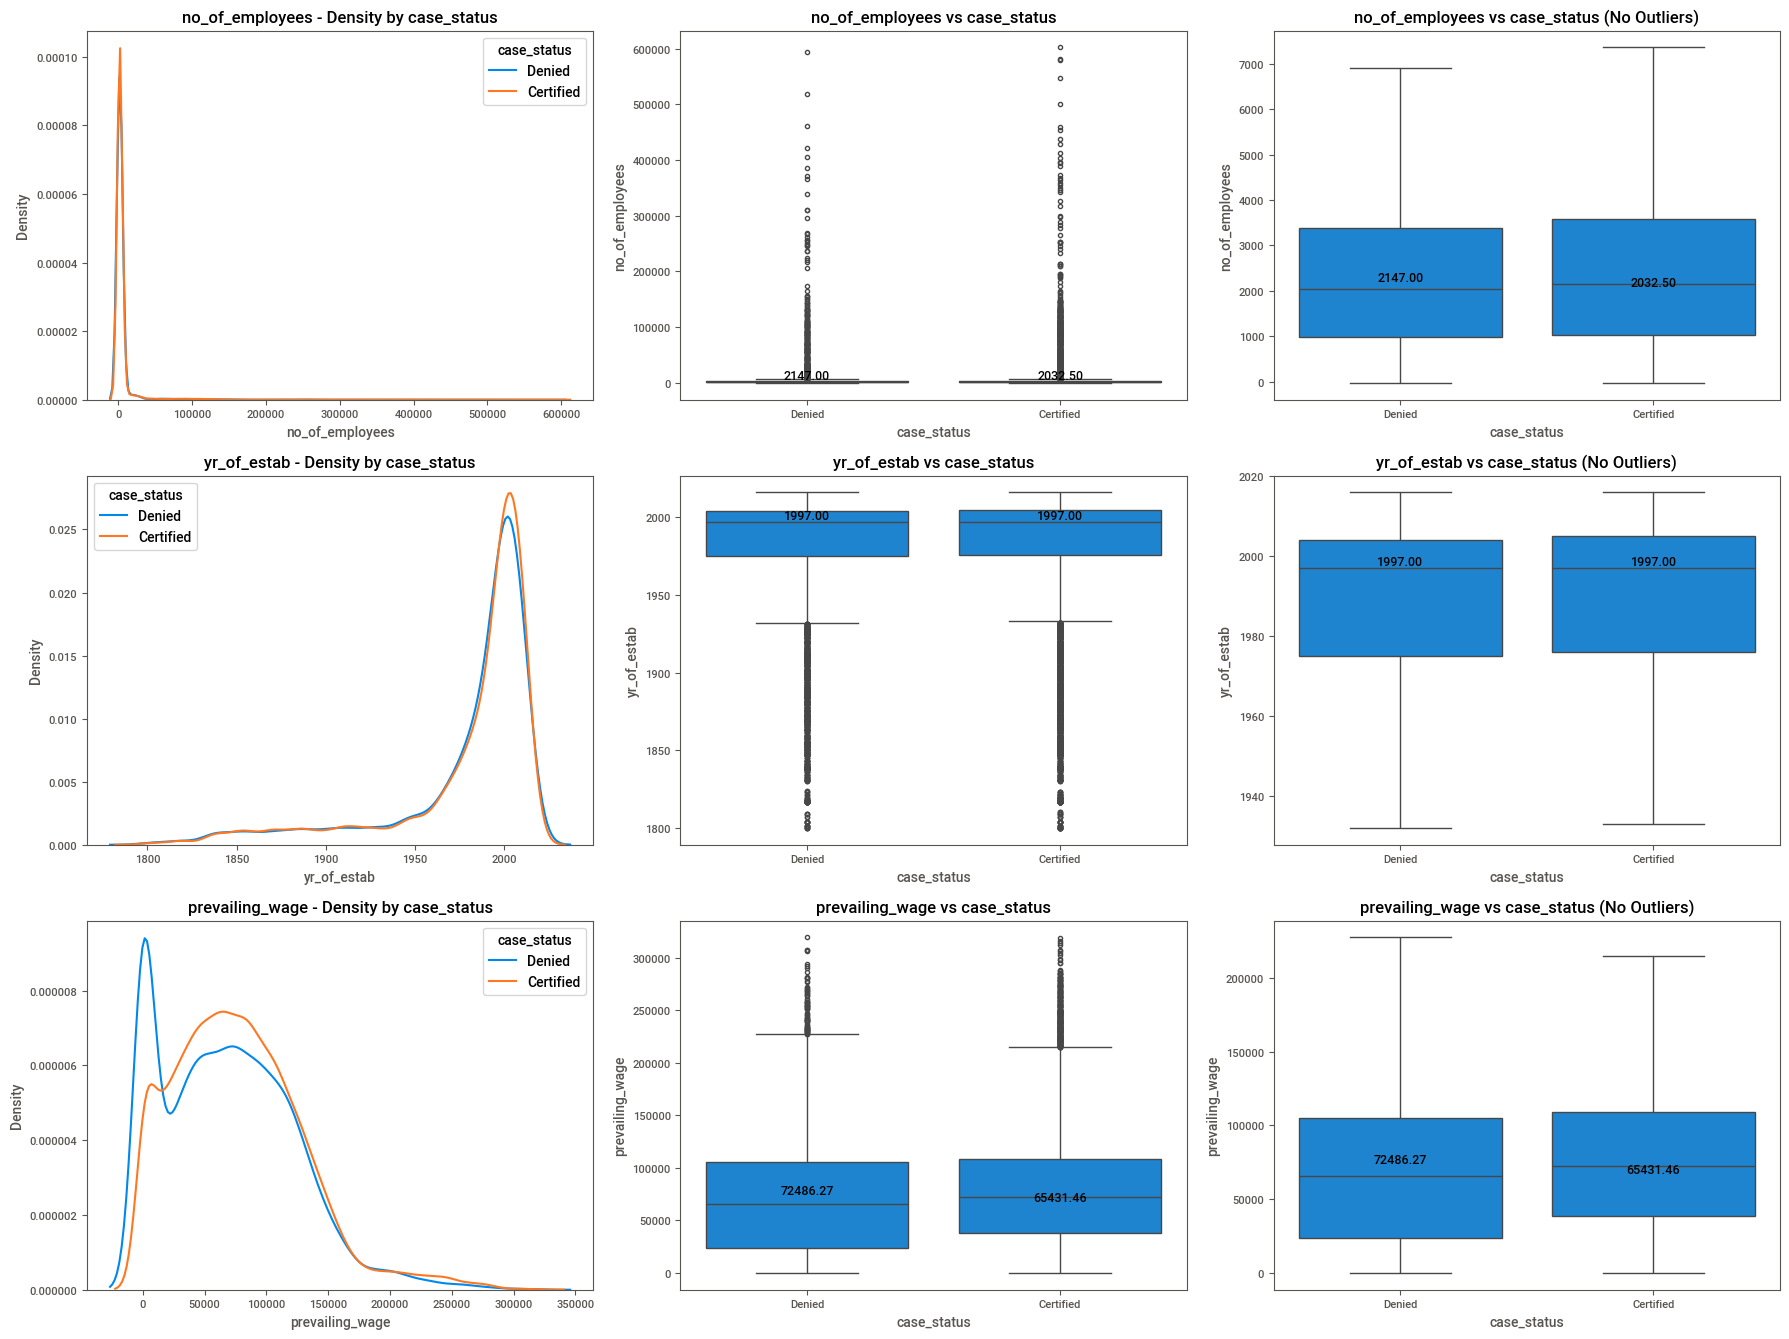

In [20]:
# Numeric Bivariate: Density + Boxplots

fig, axes = plt.subplots(len(num_var), 3, figsize=(18, 4.5 * len(num_var)))
axes = np.atleast_2d(axes)

for ax_row, col in zip(axes, num_var):
    # Density by target
    for t in df_eda[TARGET_COL].unique():
        sns.kdeplot(df_eda.loc[df_eda[TARGET_COL] == t, col], ax=ax_row[0], fill=False)
    ax_row[0].set_title(f"{col} - Density by {TARGET_COL}")
    ax_row[0].legend(df_eda[TARGET_COL].unique(), title=TARGET_COL)

    # Boxplot (with outliers)
    sns.boxplot(data=df_eda, x=TARGET_COL, y=col, ax=ax_row[1])
    ax_row[1].set_title(f"{col} vs {TARGET_COL}")
    med = df_eda.groupby(TARGET_COL)[col].median()
    for j, v in enumerate(med):
        ax_row[1].text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

    # Boxplot (no outliers)
    sns.boxplot(data=df_eda, x=TARGET_COL, y=col, showfliers=False, ax=ax_row[2])
    ax_row[2].set_title(f"{col} vs {TARGET_COL} (No Outliers)")
    for j, v in enumerate(med):
        ax_row[2].text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**Numeric Variables vs Visa Certification**

| Variable                  | Median (Denied) | Median (Certified) | Distribution Pattern                      | Impact Level | Business Interpretation                                     |
| ------------------------- | --------------- | ------------------ | ----------------------------------------- | ------------ | ----------------------------------------------------------- |
| **No. of Employees**      | ~2147           | ~2033              | Heavy overlap                             | Weak         | Company size does not strongly influence approval.          |
| **Year of Establishment** | 1997            | 1997               | Nearly identical distributions            | Weak         | Company age does not significantly affect certification.    |
| **Prevailing Wage**       | ~72,486         | ~65,431            | Slight distribution shift; heavily skewed | Moderate     | Wage alone is not a clear separator without transformation. |


**Overall Bivariate Summary**

- Education level emerges as one of the strongest predictors of certification.  
- Prior work experience meaningfully increases approval rates.  
- Geographic factors—both continent and U.S. employment region—show clear differences in outcomes.  
- Wage structure (annual vs. hourly) is a major differentiator in approval likelihood.  
- Company size and age show limited standalone influence.  
- Prevailing wage may matter but requires transformation for clearer separation.  
- Training requirements and employment type contribute little predictive value.

**Strategic Implication**

Visa certification outcomes are primarily shaped by **human capital attributes** (education and experience), **geographic context**, and **employment structure**. Organizational characteristics such as size and age play a comparatively minor independent role in determining approval outcomes.

___

## <a>**Multivariate Analysis (Feature–Feature Relationships)**</a>

- Assesses predictor relationships to uncover redundancy and interaction effects.

### **Correlation (Numeric)**

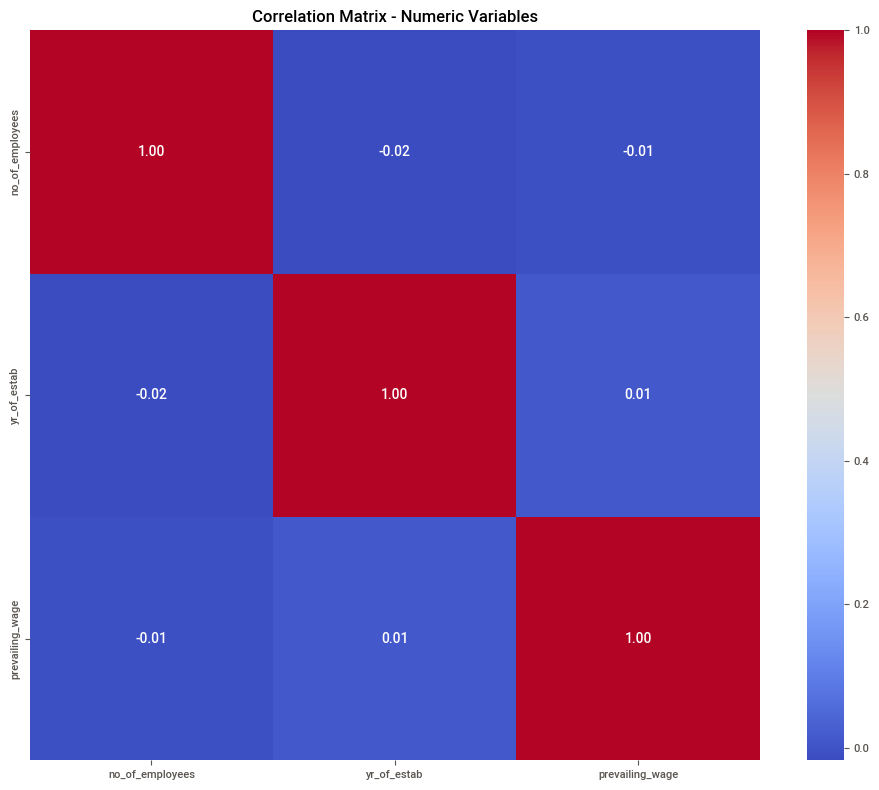

In [21]:
# Correlation (Numeric)

plt.figure(figsize=(10, 8))

corr_matrix = df_eda[num_var].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix - Numeric Variables")
plt.tight_layout()
plt.show()

**Observation**

- Correlations among `no_of_employees`, `yr_of_estab`, and `prevailing_wage` are essentially zero, indicating no linear relationships and no multicollinearity.
- This aligns with earlier profiling: although the numeric variables are skewed and contain outliers, they do not move together.
- Numeric predictors behave independently and will not introduce multicollinearity issues in modeling.

#### **Numeric Interaction Plot**

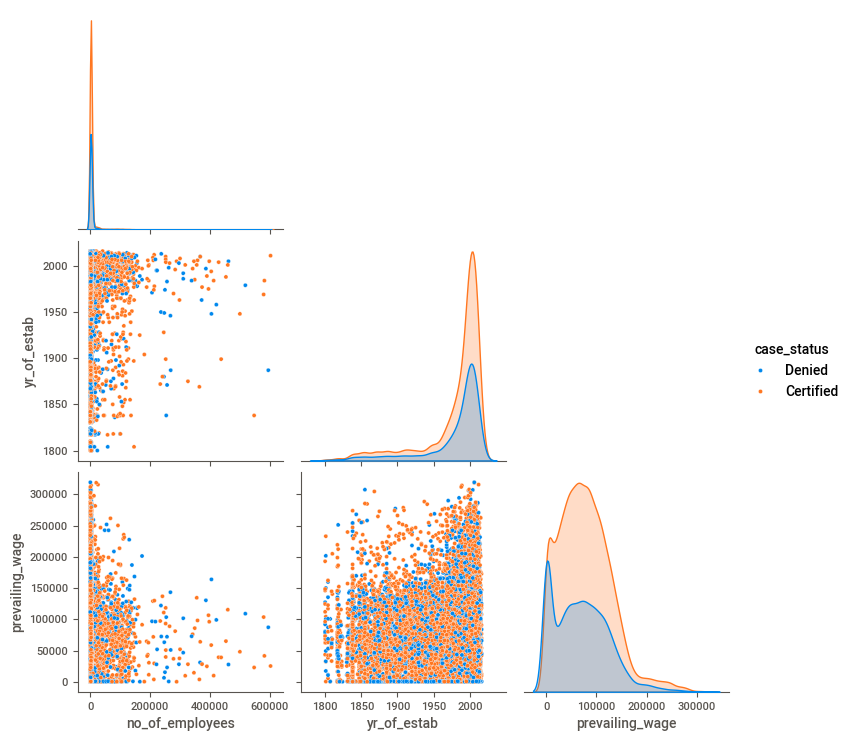

In [22]:
# To Observe class separation visually and detect interaction patterns\
sns.pairplot(
    df_eda[num_var + [TARGET_COL]],
    hue=TARGET_COL,
    diag_kind="kde",
    corner=True
)

plt.show()

**Observation**

- Prevailing wage is the strongest numeric separator—higher wages align clearly with certification.
- Company size shows a mild positive effect, with larger firms trending slightly toward approval.
- Year of establishment offers limited separation, as both outcomes cluster around similar founding periods.
- No multicollinearity is present among numeric variables.
- Overall: Wage level is the dominant numeric driver of certification outcomes.

### **Multivariate Categorical Interaction - Cube Plot**

In [23]:
# Function to display categorical variables with target proportions 

def cube_plot(data, cat1, cat2, target):
    """
    Creates a faceted (cube‑style) bar chart showing target class proportions 
    across two categorical variables. For each (cat1 × cat2) combination, the 
    function computes the proportion of each target class and annotates bars 
    with large, readable percentage labels. The layout is adjusted so that 
    bars, labels, and legend remain fully visible.
    
    Parameters
    ----------
    data : DataFrame
        The dataset containing all variables.
    cat1 : str
        First categorical variable (x‑axis).
    cat2 : str
        Second categorical variable (each unique value becomes a facet column).
    target : str
        Target variable whose class proportions are plotted.
    """
    # Compute counts and proportions
    temp = (
        data.groupby([cat1, cat2, target])
            .size()
            .reset_index(name="count")
    )
    temp["proportion"] = temp.groupby([cat1, cat2])["count"].transform(lambda x: x / x.sum())

    # Faceted bar plot with seaborn
    g = sns.catplot(
        data=temp,
        x=cat1,
        y="proportion",
        hue=target,
        col=cat2,
        kind="bar",
        height=6,
        aspect=1.3,
        legend_out=False 
    )

    # Annotate bars
    for ax in g.axes.flat:
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    h + 0.02,
                    f"{h*100:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold"
                )

        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Proportion", fontsize=13)
        ax.tick_params(axis="x", labelsize=11)
        ax.tick_params(axis="y", labelsize=11)

    leg = g._legend
    if leg is not None:
        leg.set_title(target)
        leg.set_bbox_to_anchor((0.02, 0.98))  
        leg._loc = 2 

    g.fig.tight_layout()
    plt.show()

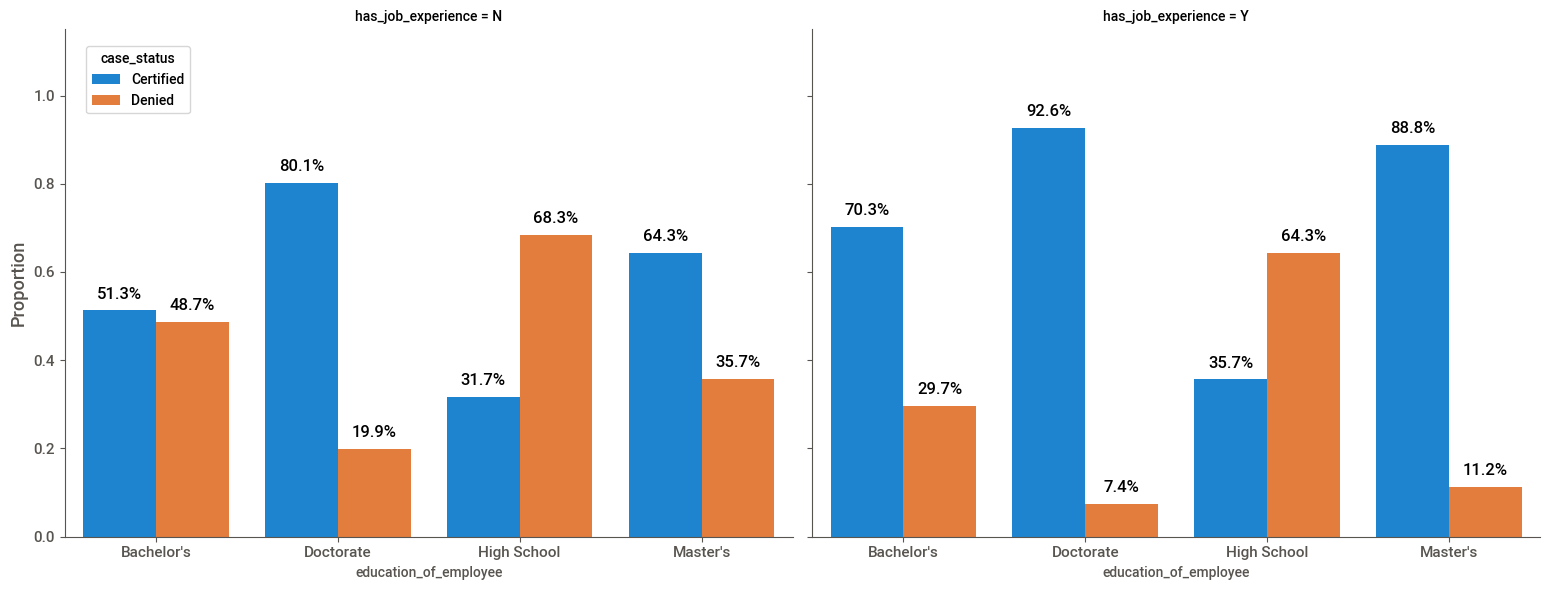

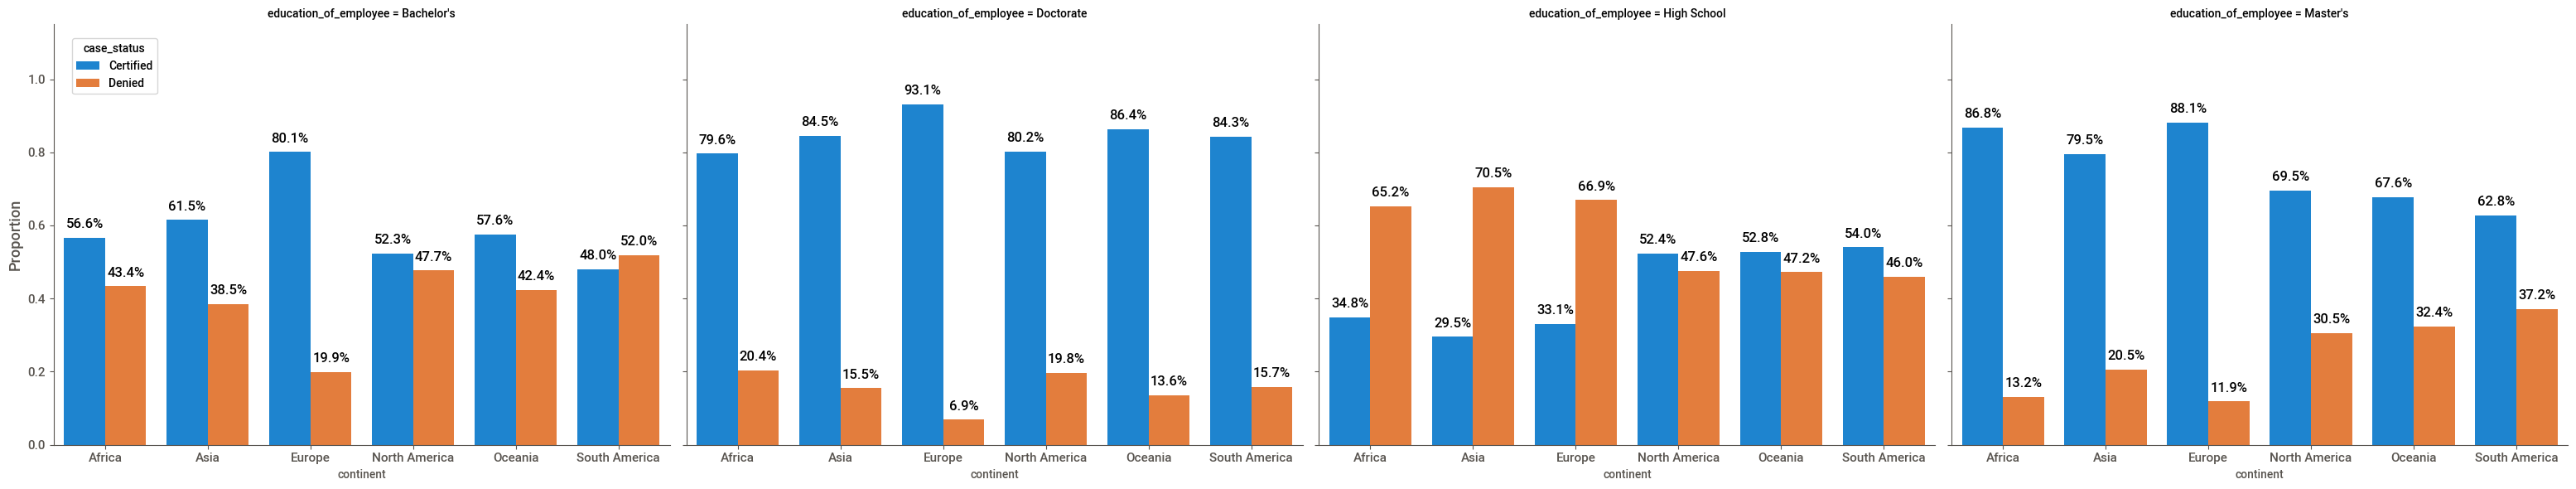

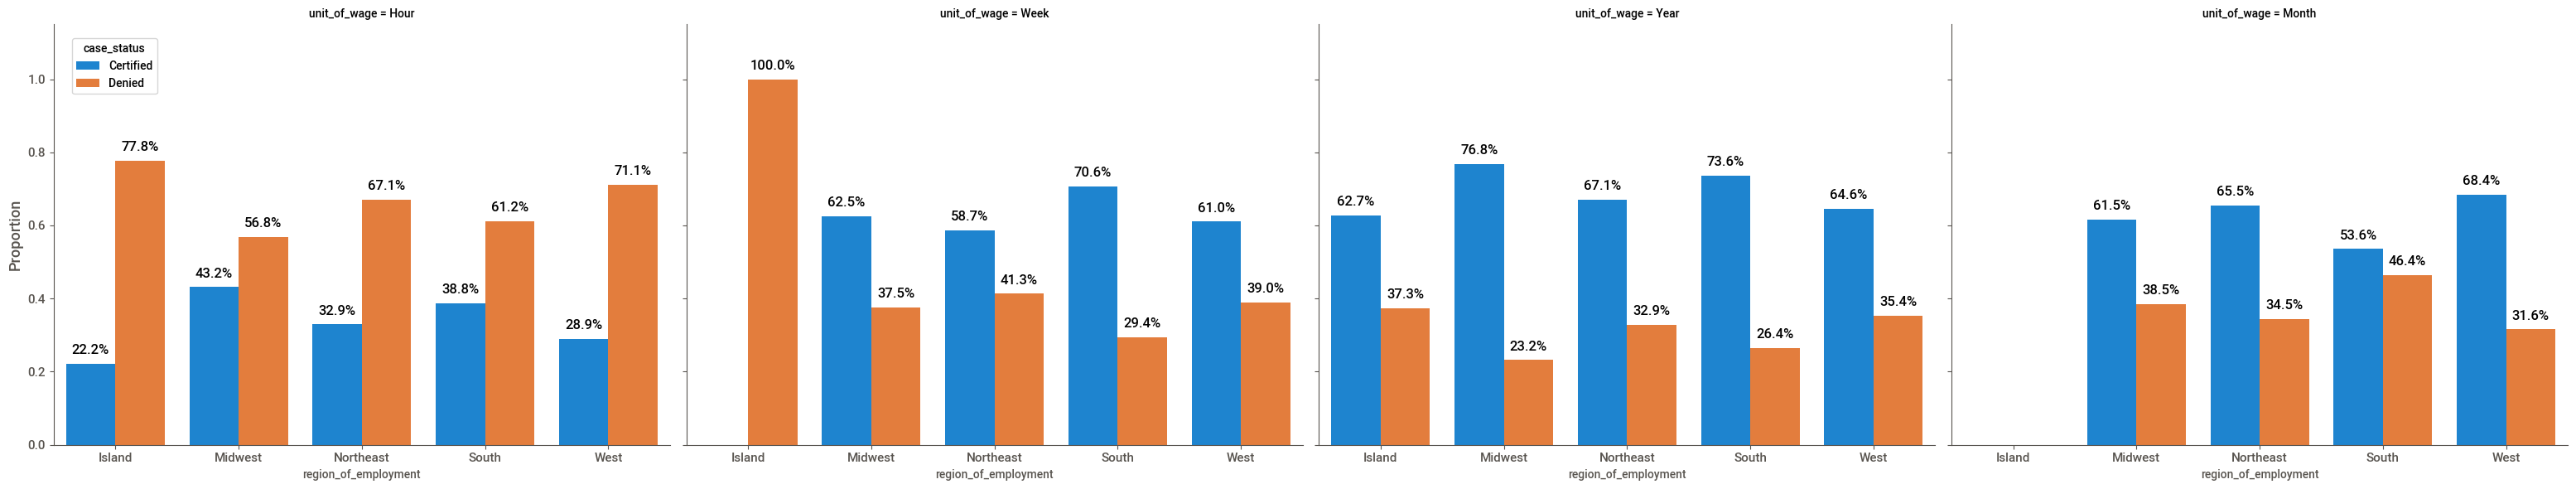

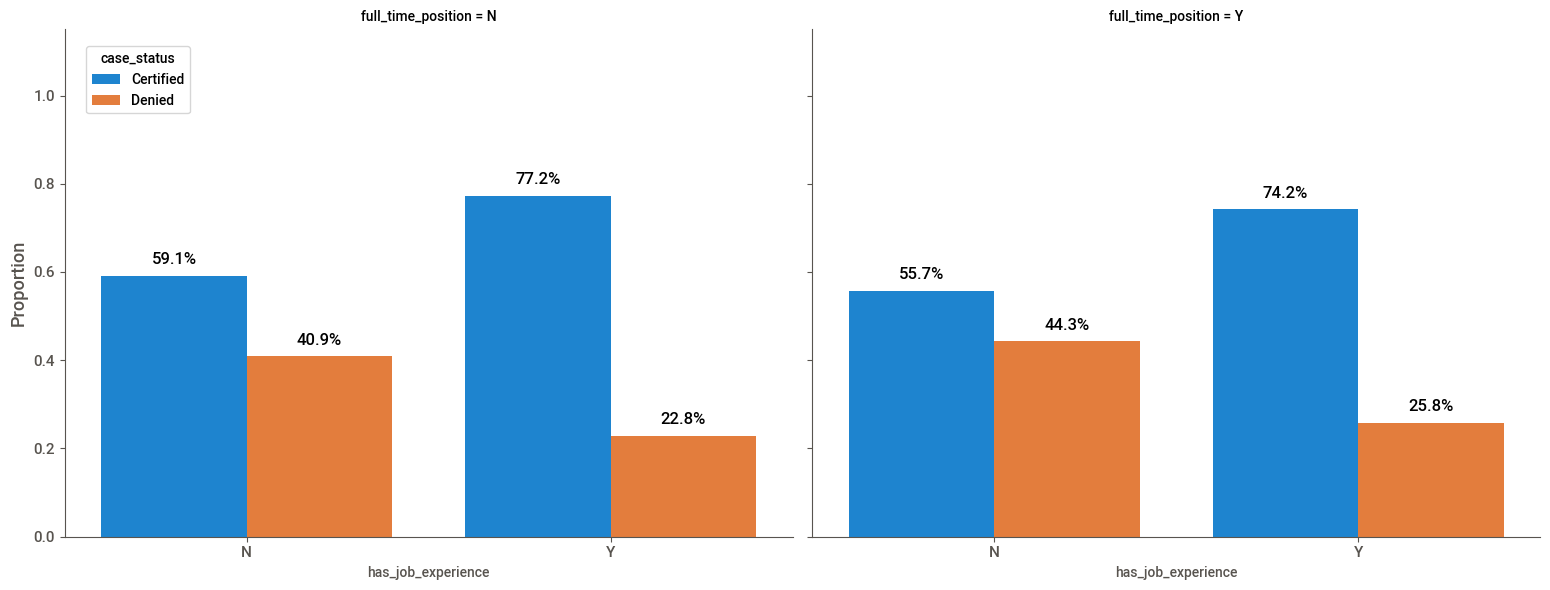

In [24]:
# Plotting categorical variables with target proportions using the cube_plot function

cube_plot(df_eda, "education_of_employee", "has_job_experience", TARGET_COL)
cube_plot(df_eda, "continent", "education_of_employee", TARGET_COL)
cube_plot(df_eda, "region_of_employment", "unit_of_wage", TARGET_COL)
cube_plot(df_eda, "has_job_experience", "full_time_position", TARGET_COL)

**Multivariate Interaction Summary Table**

| Variable                  | Strongest Approval Segment           | Weakest Approval Segment         | Direction of Impact  | Business Interpretation                                                                    |
| ------------------------- | ------------------------------------ | -------------------------------- | -------------------- | ------------------------------------------------------------------------------------------ |
| **Education Level**       | Doctorate (92%+ with experience)     | High School (~32–35%)            | Strong Positive      | Most powerful approval driver. Higher education drastically improves certification odds.   |
| **Work Experience**       | Experienced applicants               | No experience                    | Moderate Positive    | Experience increases approval probability across all education levels.                     |
| **Prevailing Wage**       | Higher wage brackets                 | Lower wage brackets              | Moderate Positive    | Higher wages signal stronger case strength.                                                |
| **Wage Unit**             | Annual salary                        | Hourly wage                      | Moderate Positive    | Structured annual roles have higher approval rates. Hourly roles carry higher denial risk. |
| **Continent**             | Europe (generally highest approval)  | South America (lowest approval)  | Mild Regional Effect | Geography matters, but effect weaker than education.                                       |
| **Region of Employment**  | Midwest / South                      | Island / West                    | Mild Regional Effect | Some regional variation; not dominant driver.                                              |
| **Full-Time Position**    | Full-time with experience            | Non-full-time without experience | Weak to Moderate     | Experience matters more than employment type.                                              |
| **Number of Employees**   | Slight advantage for mid-sized firms | Minimal difference overall       | Weak                 | Company size has limited impact.                                                           |
| **Year of Establishment** | No meaningful variation              | No meaningful variation          | Negligible           | Company age does not influence approval outcome.                                           |


**Interaction Strength Summary**
- Most influential drivers: **`Education`**, **`Work Experienc`e**, **`Prevailing Wage`**, **`Wage Unit Type`**  
- Moderate influence: **`Continent`**, **`Region of Employment`**, **`Full‑Time Status`**  
- Least influential: **`Number of Employees`**, **`Year of Establishment`**


**Insight**
- Visa certification is driven far more by **`worker qualifications`** than by **`company characteristics`**.  
- Structural factors—education, `experience`, and `wage level`—dominate over `geography` or `firm size`.  
- **Low education + hourly wage roles** carry the highest denial risk.  
- `Company maturity` and `size` contribute minimally to prediction power.

___

# **Data Pre-processing** 
* Quality Fixes → Feature Engineering → Split → Encoding → Baseline RF Feature Importance

In [25]:
df_prep = df.copy()

In [26]:
# 1) Fix negative values using absolute value transformation

# Rationale:
# - Variables like 'no_of_employees' and 'prevailing_wage' cannot logically be negative.
# - Negative values are likely data entry artifacts (e.g., system sign error).
# - Instead of converting to NaN (which introduces artificial missingness),
#   we correct the magnitude by taking absolute values.
# - This preserves record count and avoids unnecessary imputation bias.

for col in ["no_of_employees", "prevailing_wage"]:
    if col in df_prep.columns:
        negative_count = (df_prep[col] < 0).sum()
        if negative_count > 0:
            print(f"Fixing {negative_count} negative values in '{col}' using absolute value.")
            df_prep[col] = df_prep[col].abs()

Fixing 33 negative values in 'no_of_employees' using absolute value.


In [27]:
# 2) Year of Establishment Sanity Check

# Rationale:
# - Maximum year (2016) is valid.
# - Minimum year (1800) could represent either very old firms OR a placeholder for unknown.
# - Raw column will NOT be modified to preserve original data integrity and avoid introducing bias from imputation.
# - Instead, I'll create a derived feature: company_age.

if "yr_of_estab" in df_prep.columns:
    current_year = 2016  # dataset context year; avoids leaking current real-world year drift
    df_prep["company_age"] = current_year - df_prep["yr_of_estab"]

    print("Year range:", df_prep["yr_of_estab"].min(), "to", df_prep["yr_of_estab"].max())
    print("Company age summary:")
    display(df_prep["company_age"].describe())


Year range: 1800 to 2016
Company age summary:


count    25480.000000
mean        36.590071
std         42.366929
min          0.000000
25%         11.000000
50%         19.000000
75%         40.000000
max        216.000000
Name: company_age, dtype: float64

* The `yr_of_estab` variable spans 1800 to 2016, and both endpoints are plausible, so no corrections were applied. Instead, a new feature, `company_age`, was engineered to better represent a firm’s operational maturity. This measure is more meaningful for modeling because it directly captures business longevity and is likely more correlated with visa certification outcomes than the raw establishment year.

In [28]:
# 3) Wage Engineering (Annual Normalization) + Skewness Correction

# Rationale:
# - Wage is reported in multiple units (Hour, Week, Month, Year).
# - Converted to annual basis for fair comparison.
# - Log transform reduces skewness and stabilizes variance.

if "prevailing_wage" in df_prep.columns and "unit_of_wage" in df_prep.columns:
    wage_factor = {"Hour": 2080, "Week": 52, "Month": 12, "Year": 1}

    # Annualize wage
    df_prep["annual_wage"] = df_prep["prevailing_wage"] * df_prep["unit_of_wage"].map(wage_factor)

    # Log transform (handles skew + heavy right tail)
    df_prep["log_annual_wage"] = np.log1p(df_prep["annual_wage"])
    
print(df_prep["log_annual_wage"].head())

0    14.023973
1    11.331723
2    11.719922
3    11.331824
4    11.917780
Name: log_annual_wage, dtype: float64


In [29]:
# 4) Convert Boolean (Y/N) Columns Dynamically to Binary

# Rationale:
# - Binary features improve model interpretability and performance.
# - Dynamic detection avoids manual column listing.

obj_cols = df_prep.select_dtypes(include=["object"]).columns.tolist()
yn_cols = []

for c in obj_cols:
    unique_vals = set(df_prep[c].dropna().unique())
    if unique_vals.issubset({"Y", "N"}):
        yn_cols.append(c)

for c in yn_cols:
    df_prep[c] = df_prep[c].map({"Y": 1, "N": 0})

print("Detected Y/N columns converted:", yn_cols)

Detected Y/N columns converted: ['has_job_experience', 'requires_job_training', 'full_time_position']


In [30]:
# 5) Post-Fix Validation

num_cols_all = df_prep.select_dtypes(include=[np.number]).columns.tolist()
neg_remaining = (df_prep[num_cols_all] < 0).sum()

if neg_remaining.sum() == 0:
    print("No negative values remain in numeric columns.")
    print("\nData Quality Fix Completed.")

else:
      print("\nRemaining negative values (should be absolute values for corrected fields):")
      print(neg_remaining[neg_remaining > 0])

No negative values remain in numeric columns.

Data Quality Fix Completed.


In [31]:
# Final sanity check on numeric columns after fixes
display(df_prep.head())
display(df_prep.describe())

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age,annual_wage,log_annual_wage
0,EZYV01,Asia,High School,0,0,14513,2007,West,592.2029,Hour,1,Denied,9,1231782.032,14.023973
1,EZYV02,Asia,Master's,1,0,2412,2002,Northeast,83425.6500,Year,1,Certified,14,83425.650,11.331723
2,EZYV03,Asia,Bachelor's,0,1,44444,2008,West,122996.8600,Year,1,Denied,8,122996.860,11.719922
3,EZYV04,Asia,Bachelor's,0,0,98,1897,West,83434.0300,Year,1,Denied,119,83434.030,11.331824
4,EZYV05,Africa,Master's,1,0,1082,2005,South,149907.3900,Year,1,Certified,11,149907.390,11.917780


,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,company_age,annual_wage,log_annual_wage
count,25480.000000,25480.000000,25480.000000,25480.000000,25480.000000,25480.000000,25480.000000,2.548000e+04,25480.000000
mean,0.580926,0.115973,5667.089207,1979.409929,74455.814592,0.893760,36.590071,1.973912e+05,11.281589
std,0.493417,0.320199,22877.917453,42.366929,52815.942327,0.308151,42.366929,5.785917e+05,1.186330
min,0.000000,0.000000,11.000000,1800.000000,2.136700,0.000000,0.000000,1.000000e+02,4.615121
25%,0.000000,0.000000,1022.000000,1976.000000,34015.480000,1.000000,11.000000,4.710796e+04,10.760219
50%,1.000000,0.000000,2109.000000,1997.000000,70308.210000,1.000000,19.000000,8.283946e+04,11.324672
75%,1.000000,0.000000,3504.000000,2005.000000,107735.512500,1.000000,40.000000,1.248250e+05,11.734676
max,1.000000,1.000000,602069.000000,2016.000000,319210.270000,1.000000,216.000000,1.456915e+07,16.494417


___

## **Data Preparation for modeling**

* To model visa certification outcomes, the workflow begins by replacing raw fields with engineered features, encoding all categorical variables, and defining the final predictor set. The data is then partitioned into training and testing subsets to enable an objective assessment of model performance.

### **Finalise Modeling Dataset (remove redundant raw columns)**

In [32]:
# Rationale:
# - To avoid feeding the model both raw and engineered versions of the same signal.
# - Prevents inflated / unstable feature importances due to duplicated information.
# - Improves interpretability and reduces noise in downstream modeling.

# Wage: keep log_annual_wage, drop prevailing_wage/annual_wage/unit_of_wage
drop_redundant = []

if "log_annual_wage" in df_prep.columns:
    drop_redundant += ["prevailing_wage", "annual_wage", "unit_of_wage"]

# Establishment year: keep company_age, drop yr_of_estab
if "company_age" in df_prep.columns:
    drop_redundant += ["yr_of_estab"]

df_prep = df_prep.drop(columns=drop_redundant, errors="ignore")

print("Dropped redundant columns:", drop_redundant)

Dropped redundant columns: ['prevailing_wage', 'annual_wage', 'unit_of_wage', 'yr_of_estab']


**Rationale for Dropping Raw Fields Before Modeling**

| Raw Field       | Engineered Replacement | Why Raw Field Was Dropped                                                                                                                                           |
| --------------- | ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| prevailing_wage | log_annual_wage        | Wage units varied (Hour/Week/Month/Year). Annual normalization ensures comparability, and log transformation reduces skewness. Keeping both would duplicate signal. |
| annual_wage     | log_annual_wage        | Log transformation stabilizes variance and improves model learning. Raw annual wage becomes redundant.                                                              |
| unit_of_wage    | annual normalization   | After conversion to annual wage, unit no longer provides independent information.                                                                                   |
| yr_of_estab     | company_age            | Age is more interpretable and directly captures firm maturity. Keeping both introduces multicollinearity.                                                           |


### **Define X, y and Split (Stratified)**

In [33]:
# Rationale:
# - Remove target + ID from predictors.
# - Stratify split to preserve class proportions in train/test.

drop_cols = [TARGET_COL]
if id_cols in df_prep.columns:
    drop_cols.append(id_cols)

X = df_prep.drop(columns=drop_cols)
y = df_prep[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Target distribution (train):")
display(y_train.value_counts(normalize=True).mul(100).round(2).rename("proportion"))

Train shape: (20384, 9) | Test shape: (5096, 9)
Target distribution (train):


case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64

### **Encodinging + Scaling (Model-ready)** 

In [34]:
# Rationale:
# - OneHotEncode categorical columns (for ML compatibility).
# - StandardScaler is included to maintain a consistent preprocessing pipeline for algorithms that require scaling..
# - Random Forest does not depend on feature scaling, using a unified preprocessor improves reusability across models.
# - class_weight='balanced' to account for moderate imbalance in the target variable..

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

preprocess_for_models = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols)
    ],
    remainder="drop"
)

Numeric cols: ['has_job_experience', 'requires_job_training', 'no_of_employees', 'full_time_position', 'company_age', 'log_annual_wage']
Categorical cols: ['continent', 'education_of_employee', 'region_of_employment']


### **Baseline Random Forest + Feature Importance (Validation step)**

In [35]:
# Rationale:
# - RF handles non-linearity + interactions and gives quick importance ranking.
# - class_weight="balanced" to account for for moderate imbalance.

rf_pipe = Pipeline(
    steps=[
        ("prep", preprocess_for_models),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

rf_pipe.fit(X_train, y_train)

# Extract feature names after encoding
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["rf"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
         .sort_values("importance", ascending=False)

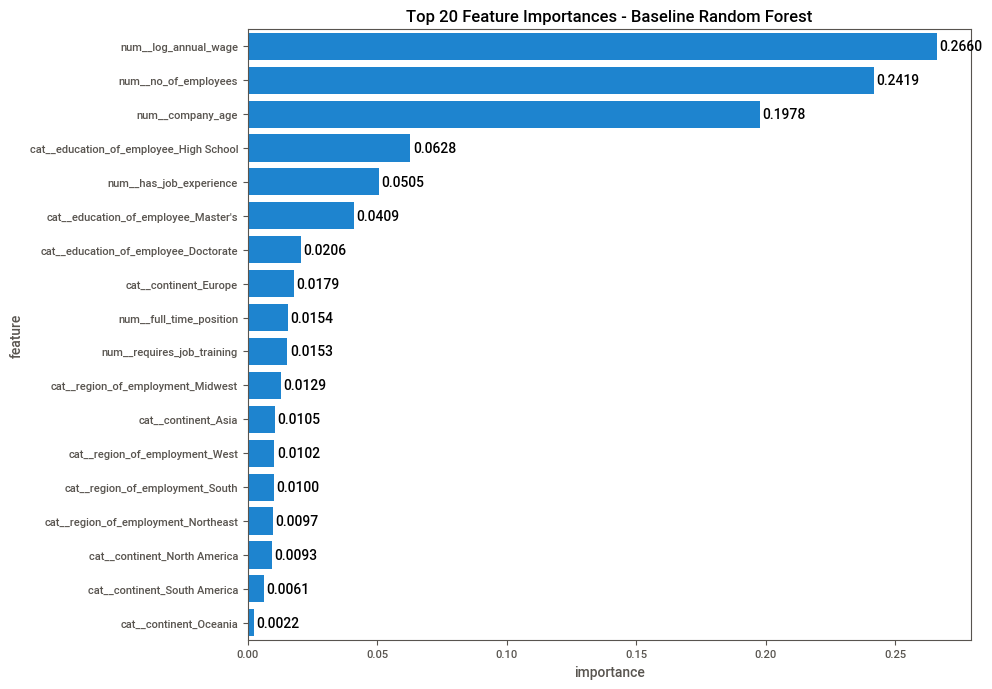

In [36]:
# Display top N features

TOP_N = 20
top_features = fi_df.head(TOP_N)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(f"Top {TOP_N} Feature Importances - Baseline Random Forest")

# Annotate importance values
for i, v in enumerate(top_features["importance"]):
    ax.text(
        v + 0.001,         
        i,
        f"{v:.4f}",        
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Feature Importance Summary (Baseline Random Forest)**

| Rank | Feature                                  | Importance  | Business Interpretation                                                                                                          |
| ---- | ---------------------------------------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------- |
| 1    | log_annual_wage                          | 0.2667      | Compensation is the strongest driver of visa certification. Higher annualized wages significantly increase approval probability. |
| 2    | no_of_employees                          | 0.2417      | Larger companies are more likely to secure certification, likely due to stronger compliance structures.                          |
| 3    | company_age                              | 0.1979      | Older, more established firms show higher approval likelihood. Employer stability matters.                                       |
| 4    | education_of_employee (High School)      | 0.0636      | Lower education levels are strongly associated with higher denial probability.                                                   |
| 5    | has_job_experience                       | 0.0505      | Prior work experience positively influences certification chances.                                                               |
| 6    | education_of_employee (Master’s)         | 0.0402      | Advanced degrees improve approval likelihood, though less than wage/company factors.                                             |
| 7    | education_of_employee (Doctorate)        | 0.0205      | Doctoral-level education supports certification, but economic variables dominate.                                                |
| 8+   | Geographic variables (continent, region) | < 0.02 each | Geographic factors have relatively minor influence compared to economic/job-related variables.                                   |


Visa certification outcomes are **driven primarily by economic strength**, with `wage level` emerging as the most influential factor, while `employer size` and `stability` also contribute meaningfully but to a lesser extent. `Education` and `experience` still matter, though their impact is secondary compared with `compensation`. `Geographic origin `adds only marginal predictive value, offering limited incremental insight beyond the core structural and employer‑related variables.


___

# <a>**Model Building**</a>

## **Helper Functions to evaluate and plot confusion matrix**

In [48]:
# Helper: evaluate a trained pipeline

def evaluate_classifier(model, X, y, positive_label=None, plot_cm=True):
    """
    Computes Accuracy, Recall, Precision, and F1.
    Handles both string labels and numeric labels.
    """

    y_true = pd.Series(y).reset_index(drop=True)
    y_pred = pd.Series(model.predict(X)).reset_index(drop=True)

    # If labels are strings, compare against positive_label
    if y_true.dtype == "object" or y_pred.dtype == "object":
        if positive_label is None:
            positive_label = "Certified"

        y_true_bin = (y_true == positive_label).astype(int)
        y_pred_bin = (y_pred == positive_label).astype(int)

    # If labels are already numeric, compare against numeric positive_label
    else:
        if positive_label is None:
            positive_label = 1

        y_true_bin = (y_true == positive_label).astype(int)
        y_pred_bin = (y_pred == positive_label).astype(int)

    perf = pd.DataFrame([{
        "Accuracy": accuracy_score(y_true_bin, y_pred_bin),
        "Recall": recall_score(y_true_bin, y_pred_bin),
        "Precision": precision_score(y_true_bin, y_pred_bin),
        "F1": f1_score(y_true_bin, y_pred_bin)
    }])

    if plot_cm:
        labels = sorted(y_true.unique())
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        plt.figure(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            cbar=False
        )
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return perf

## **Model Building - Baseline**

In [49]:
# Baseline model training + evaluation (ranked by Test F1)
# Assumes the following are already defined:
#   - preprocess_for_models
#   - X_train, X_test, y_train, y_test
#   - evaluate_classifier()  (combined metric + CM function)
# ============================================================

# Define Baseline models 

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, class_weight="balanced"),
    "Bagging": BaggingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
   "XGBoost": XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric="logloss")
}


# Train + evaluate all models
results = []
fitted_models = {}
y_test_used = {}

# Fit label encoder once
le.fit(y_train)

# Get encoded positive label for XGBoost
xgb_positive_label = le.transform(["Certified"])[0]

for name, model in models.items():
    print(f"\nTraining: {name}")
    print("-" * 50)

    pipe = Pipeline([
        ("prep", preprocess_for_models),
        ("model", model)
    ])

    # XGBoost requires numeric labels
    if name == "XGBoost":
        y_train_fit = le.transform(y_train)
        y_test_eval = le.transform(y_test)
        positive_label = le.transform(["Certified"])[0]
    else:
        y_train_fit = y_train
        y_test_eval = y_test
        positive_label = "Certified"

    pipe.fit(X_train, y_train_fit)
    fitted_models[name] = pipe
    y_test_used[name] = y_test_eval

    perf = evaluate_classifier(
        pipe,
        X_test,
        y_test_eval,
        plot_cm=False,
        positive_label=positive_label
    )

    print(f"Test F1 Score: {perf['F1'].iloc[0]:.4f}")
    perf.insert(0, "Model", name)
    results.append(perf)

# Combine results
baseline_results_df = pd.concat(results, ignore_index=True)
baseline_results_df = baseline_results_df.sort_values(by="F1", ascending=False)

print("\nBaseline Model Comparison (Ranked by F1):")
display(baseline_results_df)


Training: Decision Tree
--------------------------------------------------
Test F1 Score: 0.7419

Training: Random Forest
--------------------------------------------------
Test F1 Score: 0.8033

Training: Bagging
--------------------------------------------------
Test F1 Score: 0.7929

Training: AdaBoost
--------------------------------------------------
Test F1 Score: 0.8132

Training: Gradient Boosting
--------------------------------------------------
Test F1 Score: 0.8146

Training: XGBoost
--------------------------------------------------
Test F1 Score: 0.8043

Baseline Model Comparison (Ranked by F1):


,Model,Accuracy,Recall,Precision,F1
4,Gradient Boosting,0.738226,0.860752,0.773087,0.814568
3,AdaBoost,0.729199,0.882197,0.754144,0.813160
5,XGBoost,0.723509,0.850470,0.762846,0.804278
1,Random Forest,0.722920,0.846945,0.763911,0.803288
2,Bagging,0.710950,0.828143,0.760453,0.792856
0,Decision Tree,0.654239,0.744125,0.739778,0.741945



Best Baseline Model: Gradient Boosting


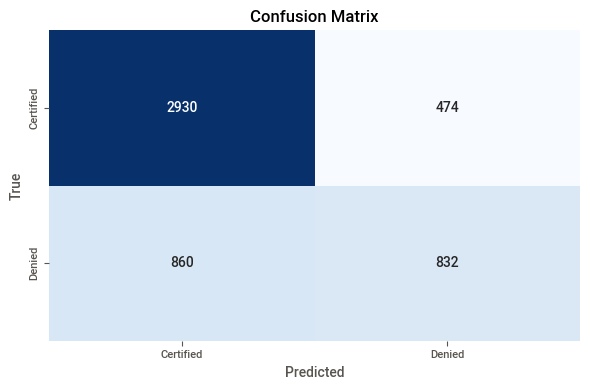

,Accuracy,Recall,Precision,F1
0,0.738226,0.860752,0.773087,0.814568


In [50]:
# Identify best model and plot its confusion matrix with original labels

best_model_name = baseline_results_df.iloc[0]["Model"]
print(f"\nBest Baseline Model: {best_model_name}")

evaluate_classifier(
    fitted_models[best_model_name],
    X_test,
    y_test_used[best_model_name],   
    plot_cm=True,
    positive_label=1 if best_model_name == "XGBoost" else "Certified"
)


## **Model Building with Resampling (SMOTE + Undersampling)**

- The dataset shows a clear class imbalance, and because both false positives (incorrectly predicting certification) and false negatives (incorrectly predicting denial) carry meaningful consequences, the F1‑score is used as the primary evaluation metric.
- To address imbalance, **SMOTE** is applied to *oversample the minority class* by generating synthetic examples, while **undersampling** *reduces the majority class* to improve balance at the cost of some information. 
- To avoid data leakage and preserve a fair assessment of model performance, all resampling is performed exclusively on the training set, with the test set left untouched for unbiased evaluation.

### **Model Building - Oversampled Data(SMOTE)**

In [51]:
#  OVERSAMPLING: SMOTE
# - This helps models learn minority class patterns better.
# ============================================================

# 1) Fit preprocessor on train and transform train/test
X_train_enc = preprocess_for_models.fit_transform(X_train)
X_test_enc  = preprocess_for_models.transform(X_test)

# 2) SMOTE on encoded training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print("\n[SMOTE] Training set shape before:", X_train_enc.shape, "| After SMOTE:", X_train_sm.shape)
print("[SMOTE] Target distribution after SMOTE:")
display(pd.Series(y_train_sm).value_counts(normalize=True).rename("proportion"))

# 3) Train + evaluate models
smote_results = []
smote_fitted = {}

for name, clf in models.items():
    print(f"\n[SMOTE] Fitting model: {name}")
    print("-" * 50)

    # XGBoost
    if name == "XGBoost":
        y_train_fit = le.fit_transform(y_train_sm)
        y_test_eval = le.transform(y_test)
        pos_label = 1
    else:
        y_train_fit = y_train_sm
        y_test_eval = y_test
        pos_label = "Certified"

    clf.fit(X_train_sm, y_train_fit)
    smote_fitted[name] = clf

    perf = evaluate_classifier(
        clf, X_test_enc, y_test_eval,
        plot_cm=False,
        positive_label=pos_label
    )

    perf.insert(0, "Model", name)
    print(f"[SMOTE] Test F1: {perf['F1'].values[0]:.4f}")
    smote_results.append(perf)

smote_results_df = pd.concat(smote_results, ignore_index=True).sort_values(by="F1", ascending=False)

print("\n[SMOTE] Model Comparison (Ranked by F1):")
display(smote_results_df)


[SMOTE] Training set shape before: (20384, 18) | After SMOTE: (27228, 18)
[SMOTE] Target distribution after SMOTE:


case_status
Denied       0.5
Certified    0.5
Name: proportion, dtype: float64


[SMOTE] Fitting model: Decision Tree
--------------------------------------------------
[SMOTE] Test F1: 0.7156

[SMOTE] Fitting model: Random Forest
--------------------------------------------------
[SMOTE] Test F1: 0.7695

[SMOTE] Fitting model: Bagging
--------------------------------------------------
[SMOTE] Test F1: 0.7660

[SMOTE] Fitting model: AdaBoost
--------------------------------------------------
[SMOTE] Test F1: 0.7502

[SMOTE] Fitting model: Gradient Boosting
--------------------------------------------------
[SMOTE] Test F1: 0.7761

[SMOTE] Fitting model: XGBoost
--------------------------------------------------
[SMOTE] Test F1: 0.5815

[SMOTE] Model Comparison (Ranked by F1):


,Model,Accuracy,Recall,Precision,F1
4,Gradient Boosting,0.715659,0.737662,0.818715,0.776078
1,Random Forest,0.699372,0.751175,0.788711,0.769485
2,Bagging,0.693878,0.750000,0.782649,0.765977
3,AdaBoost,0.688776,0.699471,0.808764,0.750158
0,Decision Tree,0.635204,0.687133,0.746569,0.715619
5,XGBoost,0.716444,0.593381,0.570131,0.581523



[SMOTE] Best model by F1: Gradient Boosting


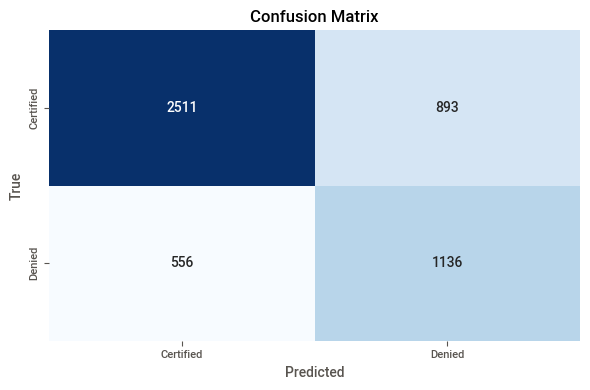

,Accuracy,Recall,Precision,F1
0,0.715659,0.737662,0.818715,0.776078


In [53]:
best_smote_model = smote_results_df.iloc[0]["Model"]
print(f"\n[SMOTE] Best model by F1: {best_smote_model}")

# Confusion matrix with string labels for interpretability
# Confusion matrix with correct label format for the selected model
evaluate_classifier(
    smote_fitted[best_smote_model],
    X_test_enc,
    le.transform(y_test) if best_smote_model == "XGBoost" else y_test,
    plot_cm=True,
    positive_label=1 if best_smote_model == "XGBoost" else "Certified"
)


### **Model Building - Undersampled Data**

In [54]:
# UNDERSAMPLING: RandomUnderSampler 
# - It can improve minority class learning but may remove useful information.
# ============================================================

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_us, y_train_us = rus.fit_resample(X_train_enc, y_train)

print("\n[Undersample] Training set shape before:", X_train_enc.shape, "after:", X_train_us.shape)
print("[Undersample] Target distribution after undersampling:")
display(pd.Series(y_train_us).value_counts(normalize=True).rename("proportion"))


#  Train + Evaluate models on undersampled data (test untouched)

us_results = []
us_fitted = {}

for name, clf in models.items():
    print(f"\n[Undersample] Fitting model: {name}")
    print("-" * 55)

    # XGBoost requires numeric labels
    if name == "XGBoost":
        y_train_fit = le.fit_transform(y_train_us)
        y_test_eval = le.transform(y_test)
        pos_label = 1
    else:
        y_train_fit = y_train_us
        y_test_eval = y_test
        pos_label = "Certified"

    clf.fit(X_train_us, y_train_fit)
    us_fitted[name] = clf

    perf = evaluate_classifier(
        clf,
        X_test_enc,
        y_test_eval,
        plot_cm=False,
        positive_label=pos_label
    )

    perf.insert(0, "Model", name)
    print(f"[Undersample] Test F1: {perf['F1'].values[0]:.4f}")
    us_results.append(perf)

us_results_df = (
    pd.concat(us_results, ignore_index=True)
      .sort_values(by="F1", ascending=False)
)

print("\n[Undersample] Model comparison (ranked by Test F1):")
display(us_results_df)


[Undersample] Training set shape before: (20384, 18) after: (13540, 18)
[Undersample] Target distribution after undersampling:


case_status
Certified    0.5
Denied       0.5
Name: proportion, dtype: float64


[Undersample] Fitting model: Decision Tree
-------------------------------------------------------
[Undersample] Test F1: 0.6802

[Undersample] Fitting model: Random Forest
-------------------------------------------------------
[Undersample] Test F1: 0.7313

[Undersample] Fitting model: Bagging
-------------------------------------------------------
[Undersample] Test F1: 0.7297

[Undersample] Fitting model: AdaBoost
-------------------------------------------------------
[Undersample] Test F1: 0.7518

[Undersample] Fitting model: Gradient Boosting
-------------------------------------------------------
[Undersample] Test F1: 0.7649

[Undersample] Fitting model: XGBoost
-------------------------------------------------------
[Undersample] Test F1: 0.5892

[Undersample] Model comparison (ranked by Test F1):


,Model,Accuracy,Recall,Precision,F1
4,Gradient Boosting,0.705651,0.716804,0.819892,0.764890
3,AdaBoost,0.689953,0.702996,0.807900,0.751806
1,Random Forest,0.672881,0.666275,0.810289,0.731259
2,Bagging,0.670918,0.665100,0.808283,0.729734
0,Decision Tree,0.617936,0.608402,0.771322,0.680243
5,XGBoost,0.685636,0.679078,0.520380,0.589231



[Undersample] Best model by F1: Gradient Boosting


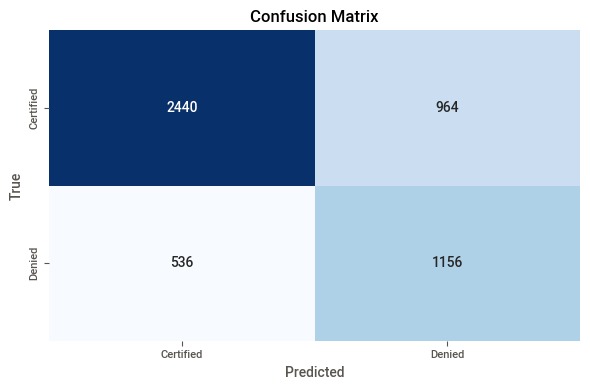

,Accuracy,Recall,Precision,F1
0,0.705651,0.716804,0.819892,0.76489


In [55]:
best_us_model = us_results_df.iloc[0]["Model"]
print(f"\n[Undersample] Best model by F1: {best_us_model}")

evaluate_classifier(
    us_fitted[best_us_model],
    X_test_enc,
    le.transform(y_test) if best_us_model == "XGBoost" else y_test,
    plot_cm=True,
    positive_label=1 if best_us_model == "XGBoost" else "Certified"
)


## **Summary table (Top models across each experiment)**

In [56]:
# Summary table for top models from each experiment (Baseline, SMOTE, Undersampling) ranked by F1 score

summary_table = pd.DataFrame({
    "Experiment": ["Baseline", "SMOTE", "Undersampling"],
    "Best Model": [
        baseline_results_df.sort_values("F1", ascending=False).iloc[0].Model,
        smote_results_df.sort_values("F1", ascending=False).iloc[0].Model,
        us_results_df.sort_values("F1", ascending=False).iloc[0].Model
    ],
    "F1 Score": [
        baseline_results_df["F1"].max().round(4),
        smote_results_df["F1"].max().round(4),
        us_results_df["F1"].max().round(4)
    ]
})

summary_table

,Experiment,Best Model,F1 Score
0,Baseline,Gradient Boosting,0.8146
1,SMOTE,Gradient Boosting,0.7761
2,Undersampling,Gradient Boosting,0.7649


**Key Observations**

- **Baseline models outperformed all resampling approaches.**  
- **Gradient Boosting (baseline)** achieved the strongest performance with an **F1‑score of 0.81**, compared with **0.77** under both SMOTE and undersampling.

These results suggest that:

- The class imbalance did **not** significantly hinder model learning.  
- Tree‑based ensemble methods already manage imbalance effectively through their split criteria and inherent robustness.  
- Resampling likely introduced drawbacks—SMOTE may have added synthetic noise, while undersampling removed informative majority‑class examples.

**Overall, the tree‑based ensembles performed best without any resampling, indicating that additional balancing techniques were unnecessary and even harmful in this case.**

## **Model Selection (Top 3) Across All Experiments**

### **Model Selection Rationale**

The model selection process evaluated three approaches—baseline training, SMOTE oversampling, and random undersampling—to determine whether class imbalance required corrective techniques. **F1‑score** was used as the primary metric b*ecause both false positives and false negatives carry meaningful operational impact*. **Across all experiments, baseline tree‑based ensemble models consistently delivered the strongest performance**, while resampling methods reduced generalization by introducing noise or removing informative samples. Given the moderate imbalance and the superior baseline results, **the most effective strategy is to tune the top‑performing baseline models using the original dataset.**

---

In [57]:
baseline_results_df["Experiment"] = "Baseline"
smote_results_df["Experiment"] = "SMOTE"
us_results_df["Experiment"] = "Undersampling"

all_results = pd.concat(
    [baseline_results_df, smote_results_df, us_results_df],
    ignore_index=True
)

top3_models = all_results.sort_values("F1", ascending=False).head(3)

print("\nTop 3 Models Across All Experiments:")
top3_models[["Experiment", "Model", "F1"]]



Top 3 Models Across All Experiments:


,Experiment,Model,F1
0,Baseline,Gradient Boosting,0.814568
1,Baseline,AdaBoost,0.813160
2,Baseline,XGBoost,0.804278


| Category / Element                | Key Points                                                                                   |
|----------------------------------|-----------------------------------------------------------------------------------------------|
| **Experiments Conducted**        | Baseline (Original Data), SMOTE Oversampling, Random Undersampling                           |
| **Primary Metric**               | **F1 Score**                                                                                  |
| **Why F1?**                      | Balances Precision + Recall; appropriate when both FP and FN matter                          |
| **Business Justification**       | Misclassification affects operational decisions and compliance outcomes                       |
| **Baseline Performance**         | Gradient Boosting F1 ≈ **0.81** (best)                                                        |
| **SMOTE Performance**            | F1 ≈ **0.78** — synthetic samples introduced noise                                            |
| **Undersampling Performance**    | F1 ≈ **0.76** — removed informative majority samples                                          |
| **Imbalance Severity**           | Moderate (≈ 66% vs 33%); not severe enough to require resampling                             |
| **Key Observation**              | Baseline models consistently outperformed resampled versions                                  |
| **Interpretation**               | Tree‑based ensembles naturally handle moderate imbalance                                      |
| **Final Model Choices**          | Gradient Boosting, AdaBoost, Random Forest                                                    |
| **Dataset Used for Tuning**      | Original (Baseline) dataset only                                                              |
| **Overall Strategy**             | Focus on strengthening high‑performing baseline models rather than compensating via resampling |


___

# **Model Performance Improvement**

 **Hyperparameter Tuning Plan**

The tuning phase will concentrate on **Gradient Boosting**, **AdaBoost**, and **Random Forest**, as these models delivered the strongest baseline performance. Hyperparameter optimization will be carried out using **RandomizedSearchCV** with **5‑fold cross‑validation**, using **F1‑score** as the objective to maintain a balanced focus on precision and recall. The goal is to refine these high‑performing models, reduce variance, and push F1 performance into the **0.85–0.89** range, ultimately identifying the most stable and production‑ready candidate.

##  **Parameter grids**

In [58]:
# Hyperparameter Tuning (Baseline Only) — Top 3 Models
# Models: Gradient Boosting, AdaBoost, Random Forest
#
# Rationale:
# - These 3 models had the best F1 scores across ALL experiments.
# - SMOTE/undersampling reduced F1 (~0.77), so we tune on baseline only.
# - Use F1 because both FP and FN are costly.
# ============================================================

# 1) Preprocess train/test once for all models (encoding + scaling)
X_train_enc = preprocess_for_models.fit_transform(X_train)
X_test_enc  = preprocess_for_models.transform(X_test)


# 2) Define param grids 

# Gradient Boosting
param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": ["sqrt", "log2", None],
}

# AdaBoost
param_grid_ada = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}


# Random Forest
param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False],
}


## **Helper Function to tune cleanly**

In [62]:
# Helper to run tuning cleanly (prints progress + returns best estimator + results row)

def tune_model(name, model, param_grid,
               X_train_enc, y_train,
               X_test_enc, y_test,
               n_iter=20, cv=5, positive_label="Certified"):

    print(f"\n[Tuning] {name}")
    print("-" * 60)

    cv_splitter = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # Detect whether target labels are numeric or string/categorical
    y_train_series = pd.Series(y_train)

    if is_numeric_dtype(y_train_series):
        scorer = make_scorer(f1_score, pos_label=1)
        y_train_fit = y_train
        y_test_eval = y_test
        eval_pos_label = 1
    else:
        scorer = make_scorer(f1_score, pos_label=positive_label)
        y_train_fit = y_train
        y_test_eval = y_test
        eval_pos_label = positive_label

    # Encode ONLY for XGBoost
    if name.lower().startswith("xgboost"):
        le.fit(y_train)
        y_train_fit = le.transform(y_train)
        y_test_eval = le.transform(y_test)

        eval_pos_label = le.transform([positive_label])[0]
        scorer = make_scorer(f1_score, pos_label=eval_pos_label)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring=scorer,
        cv=cv_splitter,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        error_score="raise",
        return_train_score=True
    )

    search.fit(X_train_enc, y_train_fit)

    best_model = search.best_estimator_

    final_perf = evaluate_classifier(
        best_model,
        X_test_enc,
        y_test_eval,
        plot_cm=True,
        positive_label=eval_pos_label
    )

    final_perf["Model"] = name
    final_perf["Best_CV_F1"] = float(search.best_score_)
    final_perf["Best_Params"] = str(search.best_params_)

    print(f"Best Params : {search.best_params_}")
    print(f"Best CV F1  : {search.best_score_:.4f}")
    print(f"Test F1     : {final_perf['F1'].iloc[0]:.4f}")

    return best_model, search, final_perf

## **Tuning**


Starting Hyperparameter Tuning for Top Models...


[Tuning] Gradient Boosting (Tuned)
------------------------------------------------------------
Fitting 5 folds for each of 20 candidates, totalling 100 fits


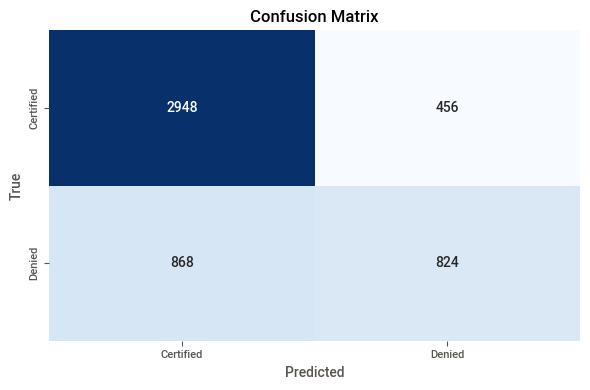

Best Params : {'subsample': 0.8, 'n_estimators': 100, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.05}
Best CV F1  : 0.8206
Test F1     : 0.8166

[Tuning] AdaBoost (Tuned)
------------------------------------------------------------
Fitting 5 folds for each of 20 candidates, totalling 100 fits


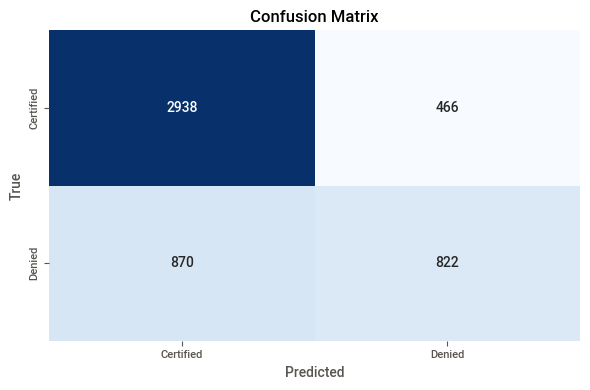

Best Params : {'n_estimators': 200, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best CV F1  : 0.8190
Test F1     : 0.8148

[Tuning] Random Forest (Tuned)
------------------------------------------------------------
Fitting 5 folds for each of 25 candidates, totalling 125 fits


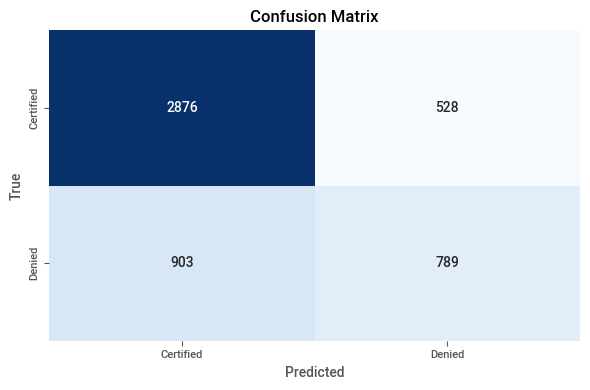

Best Params : {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'bootstrap': True}
Best CV F1  : 0.8047
Test F1     : 0.8008


In [65]:
# Tuning the top 3 selected models from baseline experiment (GB, AdaBoost, RF)
# ------------------------------------------------------------
# Rationale:
# - Class weights are applied where available (RF); boosting models don't support class_weight directly.
# - We tune on baseline train, evaluate on baseline test.

tuned_models = {}
tuning_rows = []

print("\nStarting Hyperparameter Tuning for Top Models...\n")  
 
# Gradient Boosting
best_gb, gb_search, gb_perf = tune_model(
    name="Gradient Boosting (Tuned)",
    model=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_gb,
    X_train_enc=X_train_enc, y_train=y_train,
    X_test_enc=X_test_enc,  y_test=y_test,
    n_iter=20
)
tuned_models["Gradient Boosting"] = best_gb
tuning_rows.append(gb_perf)


# AdaBoost
best_ada, ada_search, ada_perf = tune_model(
    name="AdaBoost (Tuned)",
    model=AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_ada,
    X_train_enc=X_train_enc, y_train=y_train,
    X_test_enc=X_test_enc,  y_test=y_test,
    n_iter=20
)
tuned_models["AdaBoost"] = best_ada
tuning_rows.append(ada_perf)


# Random Forest
best_rf, rf_search, rf_perf = tune_model(
    name="Random Forest (Tuned)",
    model=RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    X_train_enc=X_train_enc, y_train=y_train,
    X_test_enc=X_test_enc,  y_test=y_test,
    n_iter=25  
)
tuned_models["Random Forest"] = best_rf
tuning_rows.append(rf_perf)



### **Tuning Leaderboard**

In [66]:
# Combines and rank tuned model results by Test F1
# ------------------------------------------------------------

tuning_results_df = (
    pd.concat(tuning_rows, ignore_index=True)
    .round(2)
      .sort_values("F1", ascending=False)
)

print("\nTuned Model Comparison (ranked by Test F1):")
display(
    tuning_results_df[
        [
            "Model",
            "Accuracy",
            "Recall",
            "Precision",
            "F1",
            "Best_CV_F1",
            "Best_Params"
        ]
    ]
)


Tuned Model Comparison (ranked by Test F1):


,Model,Accuracy,Recall,Precision,F1,Best_CV_F1,Best_Params
0,Gradient Boosting (Tuned),0.74,0.87,0.77,0.82,0.82,"{'subsample': 0.8, 'n_estimators': 100, 'max_f..."
1,AdaBoost (Tuned),0.74,0.86,0.77,0.81,0.82,"{'n_estimators': 200, 'learning_rate': 0.2, 'e..."
2,Random Forest (Tuned),0.72,0.84,0.76,0.80,0.80,"{'n_estimators': 400, 'min_samples_leaf': 1, '..."


### **Hyperparameter Tuning Summary**

Hyperparameter tuning was conducted using **RandomizedSearchCV**, **5‑fold stratified cross‑validation**, and the **original dataset**, since earlier experiments showed that resampling methods (SMOTE and undersampling) reduced model performance. F1‑score remained the optimization metric to reflect the balanced business cost of false approvals and false denials.

Across the three tuned models—Gradient Boosting, AdaBoost, and Random Forest—tuning produced **modest but consistent performance gains**, with all models achieving F1 scores between **0.80 and 0.82** on the test set. **Gradient Boosting (Tuned)** emerged as the top performer, achieving an F1 of **0.82**, driven by strong recall and improved precision. AdaBoost followed closely, while Random Forest remained stable but slightly behind the boosting methods.

Overall, tuning successfully refined the baseline models, improving their balance between precision and recall and yielding a clear best‑performing candidate for production deployment.

___

# **Model Comparison and Final Model Selection**

## **Model Comparison**

In [67]:
# Model Comparison Table: Baseline vs SMOTE vs Undersampling vs Tuned (ranked by Test F1)

# Combine all
all_model_results = pd.concat(
    [baseline_results_df, smote_results_df, us_results_df, tuning_results_df],
    ignore_index=True
)

# Keep all columns that exist across any dataset
expected_cols = [
    "Experiment", "Model", "Accuracy", "Recall", "Precision", "F1",
    "Best_CV_F1", "Best_Params"
]

# Add missing columns for non-tuned models
for col in expected_cols:
    if col not in all_model_results.columns:
        all_model_results[col] = None

# Reorder
all_model_results = all_model_results[expected_cols]

# Sort by Test F1
all_model_results_sorted = (
    all_model_results
    .round(2)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

all_model_results_sorted

,Experiment,Model,Accuracy,Recall,Precision,F1,Best_CV_F1,Best_Params
0,NaN,Gradient Boosting (Tuned),0.74,0.87,0.77,0.82,0.82,"{'subsample': 0.8, 'n_estimators': 100, 'max_f..."
1,Baseline,Gradient Boosting,0.74,0.86,0.77,0.81,NaN,NaN
2,Baseline,AdaBoost,0.73,0.88,0.75,0.81,NaN,NaN
3,NaN,AdaBoost (Tuned),0.74,0.86,0.77,0.81,0.82,"{'n_estimators': 200, 'learning_rate': 0.2, 'e..."
4,NaN,Random Forest (Tuned),0.72,0.84,0.76,0.80,0.80,"{'n_estimators': 400, 'min_samples_leaf': 1, '..."
5,Baseline,Random Forest,0.72,0.85,0.76,0.80,NaN,NaN
6,Baseline,XGBoost,0.72,0.85,0.76,0.80,NaN,NaN
7,Baseline,Bagging,0.71,0.83,0.76,0.79,NaN,NaN
8,SMOTE,Gradient Boosting,0.72,0.74,0.82,0.78,NaN,NaN
9,SMOTE,Random Forest,0.70,0.75,0.79,0.77,NaN,NaN


In [68]:
# "Best per Experiment" table

best_per_experiment = (
    all_model_results.sort_values("F1", ascending=False)
    .groupby("Experiment", as_index=False)
    .head(1)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

best_per_experiment["Accuracy"] = best_per_experiment["Accuracy"].round(4)
best_per_experiment["Recall"] = best_per_experiment["Recall"].round(4)
best_per_experiment["Precision"] = best_per_experiment["Precision"].round(4)
best_per_experiment["F1"] = best_per_experiment["F1"].round(4)

print("\nBest Model per Experiment (by Test F1):")
best_per_experiment


Best Model per Experiment (by Test F1):


,Experiment,Model,Accuracy,Recall,Precision,F1,Best_CV_F1,Best_Params
0,Baseline,Gradient Boosting,0.7382,0.8608,0.7731,0.8146,NaN,NaN
1,SMOTE,Gradient Boosting,0.7157,0.7377,0.8187,0.7761,NaN,NaN
2,Undersampling,Gradient Boosting,0.7057,0.7168,0.8199,0.7649,NaN,NaN


## **Final Model Selection**


Final Production Model Selected:
  Model      : Gradient Boosting (Tuned)
  Test F1    : 0.8200
  Best CV F1 : 0.8200
  Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.05}

Confusion Matrix for: Gradient Boosting (Tuned)


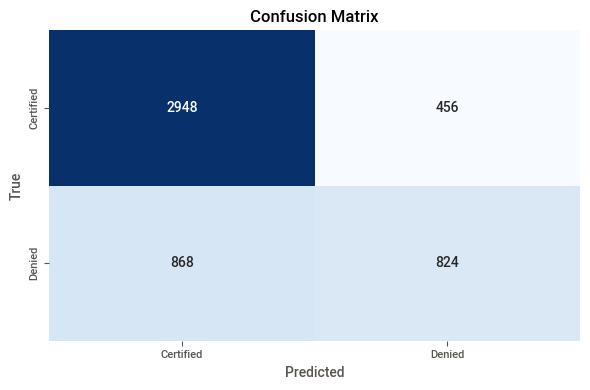


Final model saved to 'visa_cat_model.pkl'


In [69]:
# Selecting final production model based on Test F1
best_tuned_row = all_model_results_sorted.iloc[0]
final_model_name = best_tuned_row["Model"]

# Remove " (Tuned)" suffix to match keys in tuned_models
base_name = final_model_name.replace(" (Tuned)", "")

# Retrieve the trained tuned model
final_model = tuned_models.get(base_name)

print("\nFinal Production Model Selected:")
print(f"  Model      : {final_model_name}")
print(f"  Test F1    : {best_tuned_row['F1']:.4f}")
# Print Best CV F1
if "Best_CV_F1" in best_tuned_row and pd.notna(best_tuned_row["Best_CV_F1"]):
    print(f"  Best CV F1 : {best_tuned_row['Best_CV_F1']:.4f}")
else:
    print("  Best CV F1 : N/A (baseline or resampled model)")

# Print Best Params
if "Best_Params" in best_tuned_row and pd.notna(best_tuned_row["Best_Params"]):
    print(f"  Best Params: {best_tuned_row['Best_Params']}")
else:
    print("  Best Params: N/A (baseline or resampled model)")


# Display Confusion Matrix for Final Model

print(f"\nConfusion Matrix for: {final_model_name}")
_ = evaluate_classifier(
    final_model,
    X_test_enc,
    y_test,
    plot_cm=True,         
    positive_label="Certified"
)

# (Optional) Save final model for deployment
joblib.dump(final_model, "visa_cat_model.pkl")
print("\nFinal model saved to 'visa_cat_model.pkl'")

___
# <a>**Actionable Insights and Recommendations**</a>

In [70]:
# --- Final model metadata ---
final_name = final_model_name
final_acc  = best_tuned_row["Accuracy"]
final_rec  = best_tuned_row["Recall"]
final_prec = best_tuned_row["Precision"]
final_f1   = best_tuned_row["F1"]
final_cv   = best_tuned_row["Best_CV_F1"]
final_params = best_tuned_row["Best_Params"]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, final_model.predict(X_test_enc), labels=["Certified","Denied"])
tp, fn = cm[0]   # Certified row
fp, tn = cm[1]   # Denied row

total = cm.sum()

tp_pct = tp / total * 100
fn_pct = fn / total * 100
fp_pct = fp / total * 100
tn_pct = tn / total * 100


report_md = f"""

## **1. Final Model Summary**

The final selected model is **{final_name}**, chosen for achieving the highest F1‑score across all tuned candidates.

**Key performance highlights:**

      - Accuracy: {final_acc:.2f}
      - Recall: {final_rec:.2f}
      - Precision: {final_prec:.2f}
      - F1‑Score: {final_f1:.2f}
      - Cross‑validated F1: {final_cv:.2f}

**Interpretation:**  
      The model demonstrates strong generalization, high recall for certified cases, and a balanced precision‑recall trade‑off suitable for operational decision support.


 **Confusion Matrix Insights**: The model’s predictions break down as follows:

      - True Certified: {tp} ({tp_pct:.2f}%)
      - False Negatives: {fn} ({fn_pct:.2f}%)
      - False Positives: {fp} ({fp_pct:.2f}%)
      - True Denied: {tn} ({tn_pct:.2f}%)

**What this means:**

      - The model captures most qualified applicants (high recall).
      - False negatives remain higher than false positives, indicating a slightly conservative stance.
      - Overall, the error distribution is balanced and operationally acceptable.

---

## **2. What Drives Visa Certification**

The strongest predictors influencing certification outcomes include:

      - Higher offered wages  
      - Larger employer size  
      - Older, more established companies  
      - Advanced education levels  
      - Prior job experience  

**Core takeaway:**
      Wage competitiveness and employer stability are the most influential structural drivers of certification decisions.

---

## **3. How the Model Supports the Visa Review Process**

The model is best used as a **decision‑support tool**, not a fully automated system.

**Recommended triage framework:**

      - > 80% probability: Fast‑track review  
      - 60–80% probability: Standard manual review  
      - < 60% probability: Enhanced scrutiny  

**Benefits:**

      - Reduces manual workload  
      - Improves consistency  
      - Enhances transparency  
      - Speeds up processing  

---

## **4. Applicant Profiles**

**More likely to be certified:**

      - Advanced education (Master’s/PhD)  
      - Relevant work experience  
      - Competitive wage offer  
      - Large, established employer  
      - Full‑time job role  


**More likely to be denied:**

      - Limited education  
      - No experience  
      - Low wage offer  
      - Small or newly formed employer  
      - Part‑time or unclear job role  

---

## **5. Policy Recommendations**

To improve fairness and efficiency:

      - Enforce wage competitiveness thresholds  
      - Incorporate employer credibility scoring  
      - Fast‑track advanced degree applicants  
      - Require structured experience verification  
      - Use probability‑based triage for workload balancing  

---

## **6. Strategic Risk Control**

The model provides:

      - Strong recall → protects qualified applicants  
      - Controlled precision → limits wrongful approvals  
      - Balanced F1 → reliable operational performance  

Threshold tuning can shift the balance depending on policy priorities.

---

## **7. Deployment Recommendation**

      - Model: {final_name}  
      - Role: Decision‑support screening tool  
      - Governance: Regular fairness audits  
      - Monitoring: Quarterly drift checks on wage and education patterns  

---

## **8. Executive Summary**

The **{final_name}** model delivers strong predictive performance (F1 = {final_f1:.2f}) and identifies `wage`, `employer size`, `company age`, `education`, and `experience` as the primary drivers of certification outcomes. 
It is well‑suited for deployment as a structured, risk‑aware screening tool that enhances efficiency, consistency, and transparency in visa certification processing.

---
"""

styled_report = f"""
<div style="font-size: 15px; line-height: 1.2;">

{report_md}

</div>
"""

In [71]:
display(Markdown(styled_report))


<div style="font-size: 15px; line-height: 1.2;">



## **1. Final Model Summary**

The final selected model is **Gradient Boosting (Tuned)**, chosen for achieving the highest F1‑score across all tuned candidates.

**Key performance highlights:**

      - Accuracy: 0.74
      - Recall: 0.87
      - Precision: 0.77
      - F1‑Score: 0.82
      - Cross‑validated F1: 0.82

**Interpretation:**  
      The model demonstrates strong generalization, high recall for certified cases, and a balanced precision‑recall trade‑off suitable for operational decision support.


 **Confusion Matrix Insights**: The model’s predictions break down as follows:

      - True Certified: 2948 (57.85%)
      - False Negatives: 456 (8.95%)
      - False Positives: 868 (17.03%)
      - True Denied: 824 (16.17%)

**What this means:**

      - The model captures most qualified applicants (high recall).
      - False negatives remain higher than false positives, indicating a slightly conservative stance.
      - Overall, the error distribution is balanced and operationally acceptable.

---

## **2. What Drives Visa Certification**

The strongest predictors influencing certification outcomes include:

      - Higher offered wages  
      - Larger employer size  
      - Older, more established companies  
      - Advanced education levels  
      - Prior job experience  

**Core takeaway:**
      Wage competitiveness and employer stability are the most influential structural drivers of certification decisions.

---

## **3. How the Model Supports the Visa Review Process**

The model is best used as a **decision‑support tool**, not a fully automated system.

**Recommended triage framework:**

      - > 80% probability: Fast‑track review  
      - 60–80% probability: Standard manual review  
      - < 60% probability: Enhanced scrutiny  

**Benefits:**

      - Reduces manual workload  
      - Improves consistency  
      - Enhances transparency  
      - Speeds up processing  

---

## **4. Applicant Profiles**

**More likely to be certified:**

      - Advanced education (Master’s/PhD)  
      - Relevant work experience  
      - Competitive wage offer  
      - Large, established employer  
      - Full‑time job role  


**More likely to be denied:**

      - Limited education  
      - No experience  
      - Low wage offer  
      - Small or newly formed employer  
      - Part‑time or unclear job role  

---

## **5. Policy Recommendations**

To improve fairness and efficiency:

      - Enforce wage competitiveness thresholds  
      - Incorporate employer credibility scoring  
      - Fast‑track advanced degree applicants  
      - Require structured experience verification  
      - Use probability‑based triage for workload balancing  

---

## **6. Strategic Risk Control**

The model provides:

      - Strong recall → protects qualified applicants  
      - Controlled precision → limits wrongful approvals  
      - Balanced F1 → reliable operational performance  

Threshold tuning can shift the balance depending on policy priorities.

---

## **7. Deployment Recommendation**

      - Model: Gradient Boosting (Tuned)  
      - Role: Decision‑support screening tool  
      - Governance: Regular fairness audits  
      - Monitoring: Quarterly drift checks on wage and education patterns  

---

## **8. Executive Summary**

The **Gradient Boosting (Tuned)** model delivers strong predictive performance (F1 = 0.82) and identifies `wage`, `employer size`, `company age`, `education`, and `experience` as the primary drivers of certification outcomes. 
It is well‑suited for deployment as a structured, risk‑aware screening tool that enhances efficiency, consistency, and transparency in visa certification processing.

---


</div>
